# Notebook 03 — Event-Conditioned Reliability Analysis
**Thesis Chapter 7** | **Input:** `data/2_events.csv` | **Output:** `data/3_results.csv`

---

## Purpose — three research questions

| RQ | Question | Section |
|----|---------|---------|
| RQ1 | What does reconstruction reveal about campaign-wide reliability? | §7.1 — global PDR, rolling time series, burst distribution |
| RQ2 | How does reliability vary across environmental and operational events? | §7.3–7.6 — event-conditioned PDR for all 17 events |
| RQ3 | Which conditions are most strongly associated with loss risk? | §7.7 — logistic regression, odds ratios |

## Filtered dataset
All event-conditioned analysis uses `df_link` — outage intervals excluded:
```python
df_link = df[~df['is_outage']].copy()
```
This ensures PDR variation reflects radio-channel conditions, not infrastructure downtime.


## 0 · Imports & Load

In [2]:
import pandas as pd
from scipy import stats
from sklearn.linear_model import LogisticRegression
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path('../data')
df = pd.read_csv(DATA_DIR / '2_events.csv')
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values(['device_id', 'time']).reset_index(drop=True)

# filtered dataset — outage intervals excluded only
df_link = df[~df['is_outage']].copy().reset_index(drop=True)

print(f'Full dataset : {len(df):,} rows')
print(f'df_link      : {len(df_link):,} rows')
print(f'Excluded     : {len(df)-len(df_link):,} rows (outages)')
print(f'Devices      : {sorted(df_link["device_id"].unique())}')
print(f'Campaign     : {df["time"].min().date()} → {df["time"].max().date()}')


Full dataset : 2,634,930 rows
df_link      : 2,634,431 rows
Excluded     : 499 rows (outages)
Devices      : ['ED0', 'ED1', 'ED2', 'ED3', 'ED4', 'ED5']
Campaign     : 2024-10-01 → 2025-09-30


In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams.update({
    'font.family':'serif','font.size':10,'axes.titlesize':11,
    'axes.labelsize':10,'xtick.labelsize':9,'ytick.labelsize':9,
    'legend.fontsize':9,'figure.dpi':150,'savefig.dpi':300,
    'savefig.bbox':'tight','axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.3,'grid.linestyle':'--',
})
C = {'blue':'#0077BB','orange':'#EE7733','green':'#009988',
     'red':'#CC3311','purple':'#AA3377','navy':'#004488','grey':'#BBBBBB',
     'brown':'#882255','teal':'#44AA99','yellow':'#DDCC77'}
DEVICE_COLORS = [C['blue'],C['orange'],C['green'],C['red'],C['purple'],C['navy']]
TOA_MS = {7:71.9, 8:133.6, 9:246.8, 10:452.6, 11:987.1, 12:1810.4}
FIG_DIR = Path('../figures'); FIG_DIR.mkdir(exist_ok=True)

def save_fig(fig, name):
    fig.savefig(FIG_DIR/f'{name}.pdf')
    fig.savefig(FIG_DIR/f'{name}.png')
    print(f'  Saved: figures/{name}')
    plt.show()

def pdr_grp(grp):
    rx=len(grp); lost=int(grp['mac_to_radio_loss'].sum())
    return rx/(rx+lost)*100 if (rx+lost)>0 else 0

def burst_rate_grp(grp):
    return (grp['mac_to_radio_loss']>=3).mean()*100

print('Style ready.')


Style ready.


## 1 · Baseline PDR & Rolling Time Series  *(§7.1)*

Per-device `PDR_link` is the baseline metric for all event-conditioned analysis.  
The near-uniform PDR across devices with vastly different link budgets is the  
first evidence for the collision-dominated loss hypothesis.

The rolling time series shows PDR stability over the full campaign and  
confirms that outage exclusion (`is_outage`) correctly isolates environmental losses.


In [4]:
print(f"{'Device':<8} {'Dist(m)':^8} {'CW':^4} {'WW':^4} {'Received':^10} "
      f"{'Link Lost':^11} {'PDR_link':^10}")
print('-' * 65)

pdrs = {}
for dev, g in df_link.groupby('device_id'):
    rx   = len(g)
    lost = int(g['mac_to_radio_loss'].sum())
    pdr  = rx / (rx + lost) * 100
    pdrs[dev] = pdr
    dist = int(g['distance'].iloc[0])
    cw   = int(g['c_walls'].iloc[0])
    ww   = int(g['w_walls'].iloc[0])
    print(f"{dev:<8} {dist:^8} {cw:^4} {ww:^4} {rx:^10,} {lost:^11,} {pdr:^10.2f}%")

print('-' * 65)
pdr_range = max(pdrs.values()) - min(pdrs.values())
print(f"PDR range across devices: {pdr_range:.2f} pp")
print(f"\nOnly {pdr_range:.2f} pp spread across devices with vastly different link budgets — "
      f"consistent with collision-dominated loss rather than signal quality degradation.")


Device   Dist(m)   CW   WW   Received   Link Lost   PDR_link 
-----------------------------------------------------------------
ED0         10     0    0    440,090      9,331      97.92   %
ED1         8      1    0    434,476     11,767      97.36   %
ED2         23     0    2    440,847      8,419      98.13   %
ED3         18     1    2    433,483     12,673      97.16   %
ED4         37     0    5    435,337     10,353      97.68   %
ED5         40     2    2    450,198      4,459      99.02   %
-----------------------------------------------------------------
PDR range across devices: 1.86 pp

Only 1.86 pp spread across devices with vastly different link budgets — consistent with collision-dominated loss rather than signal quality degradation.


  Saved: figures/03_b1_rolling_pdr_individual_7D


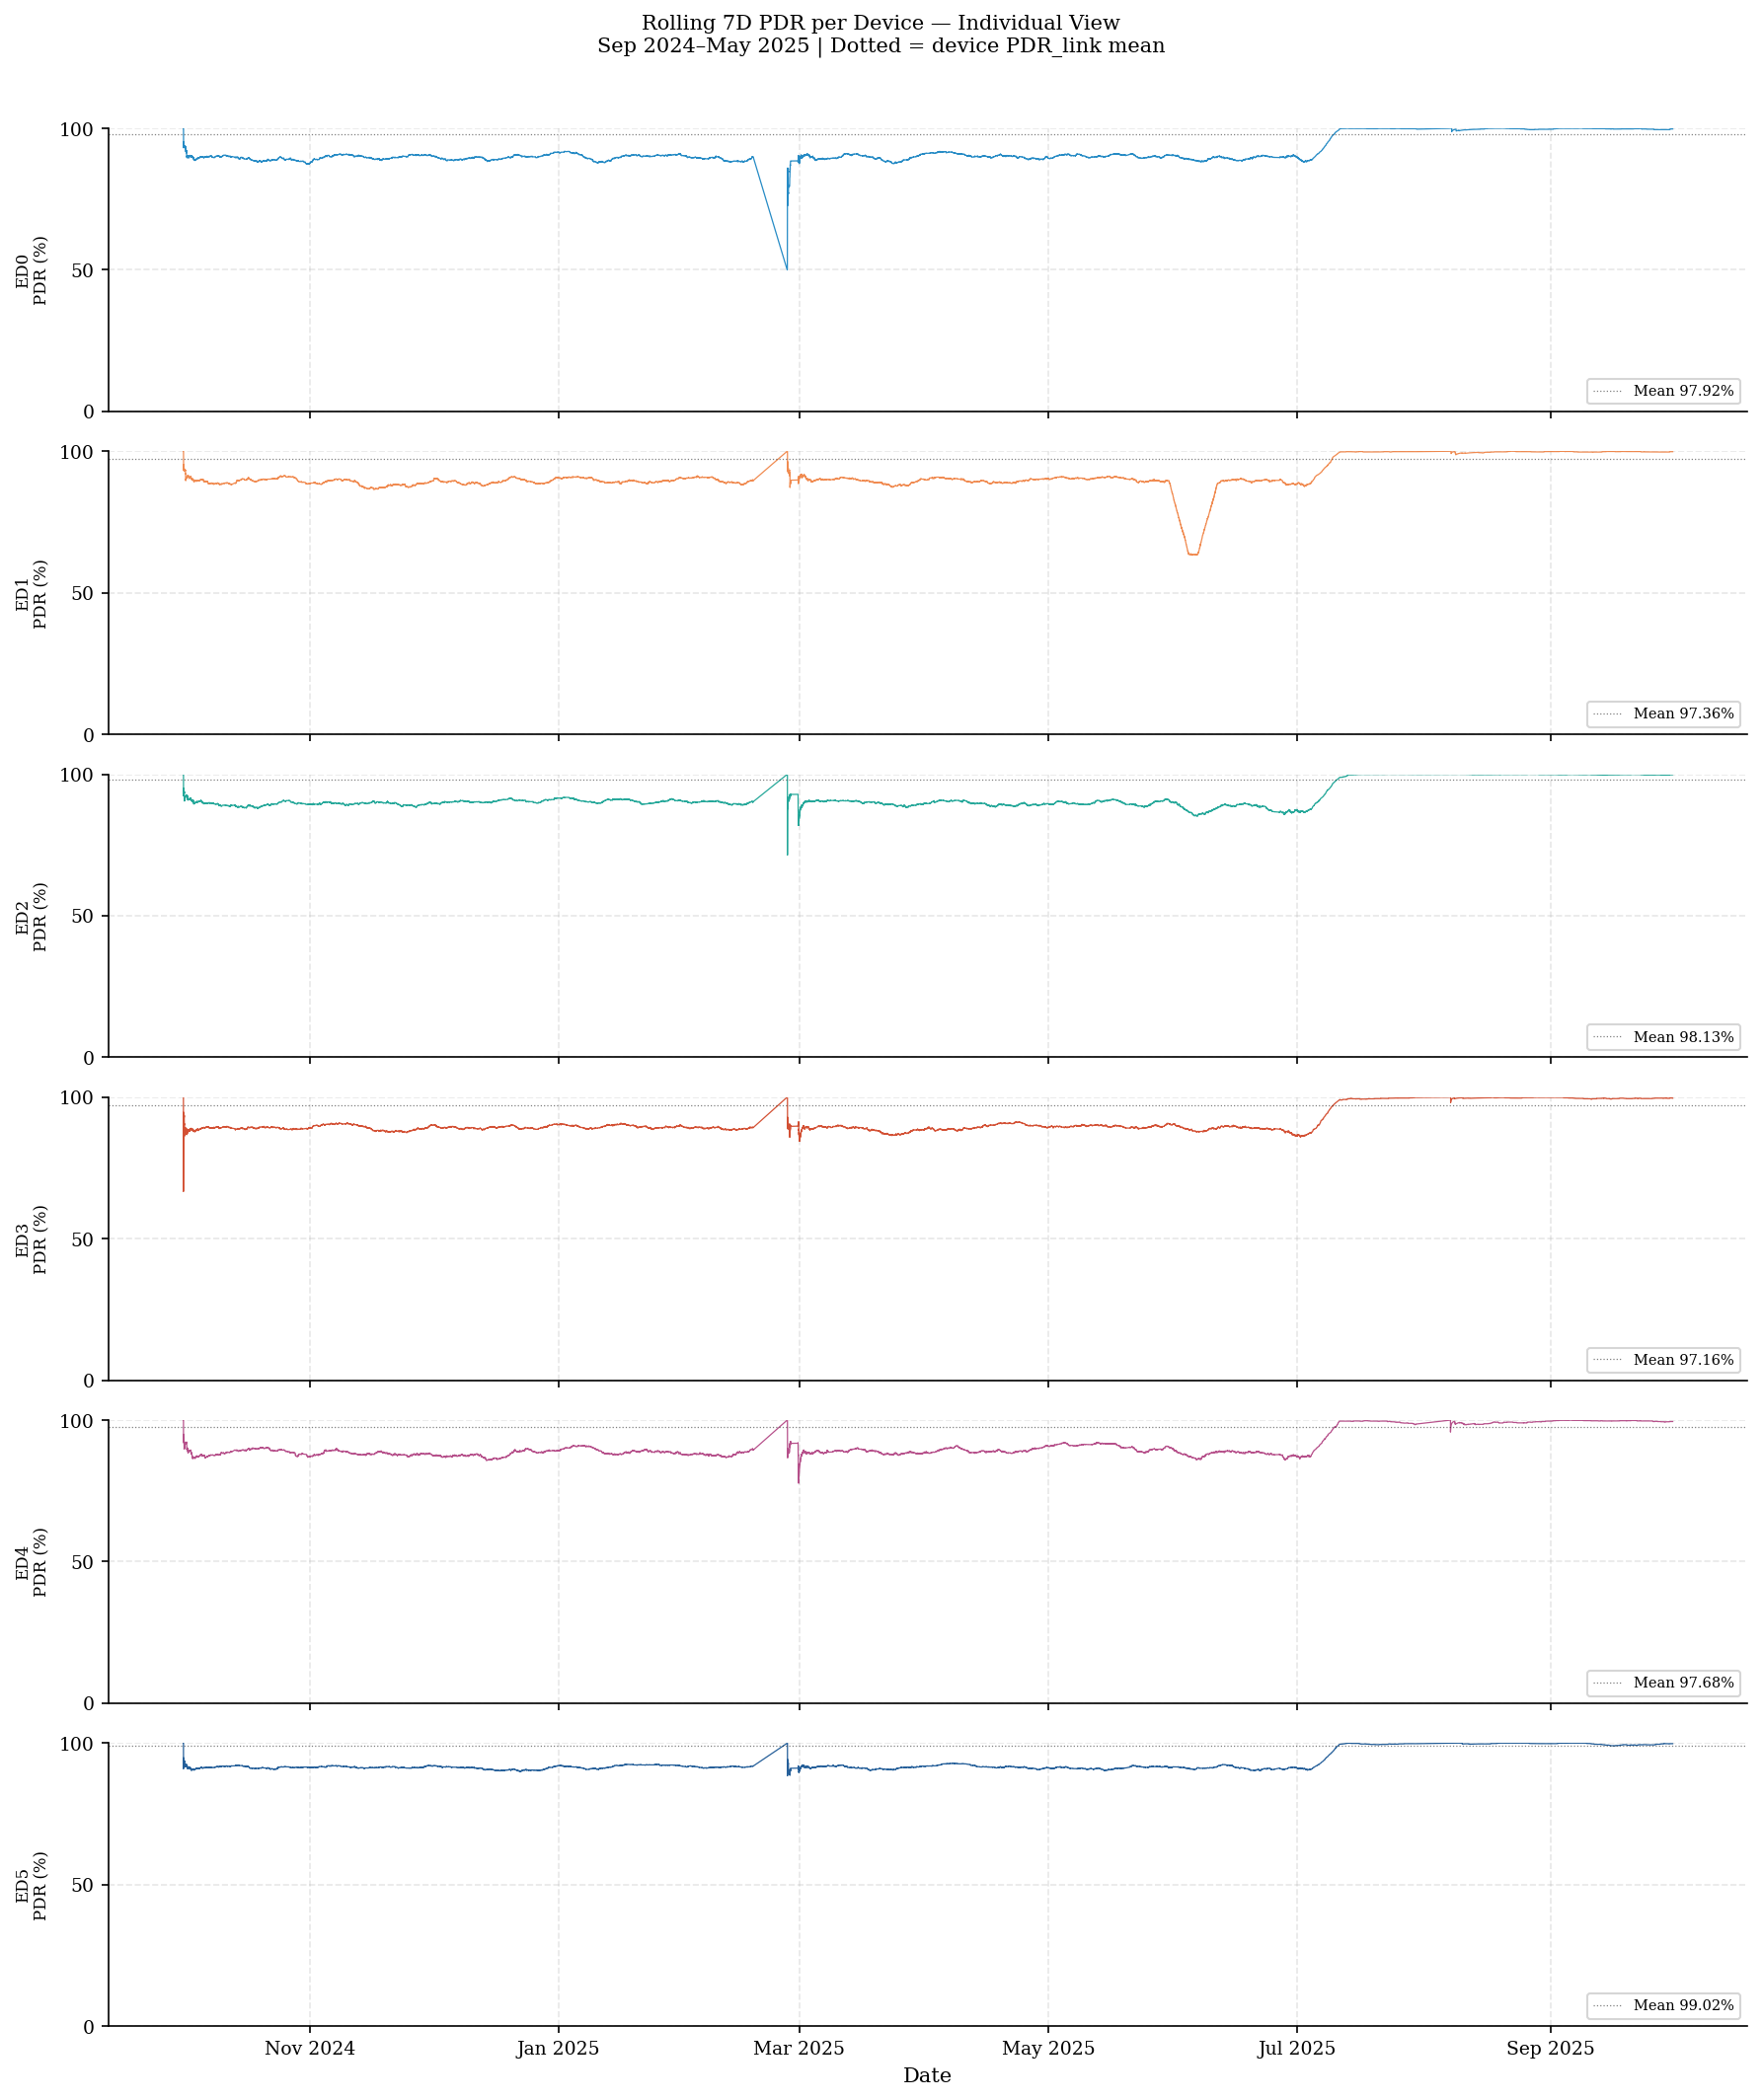

  Saved: figures/03_b2_rolling_pdr_superimposed_7D


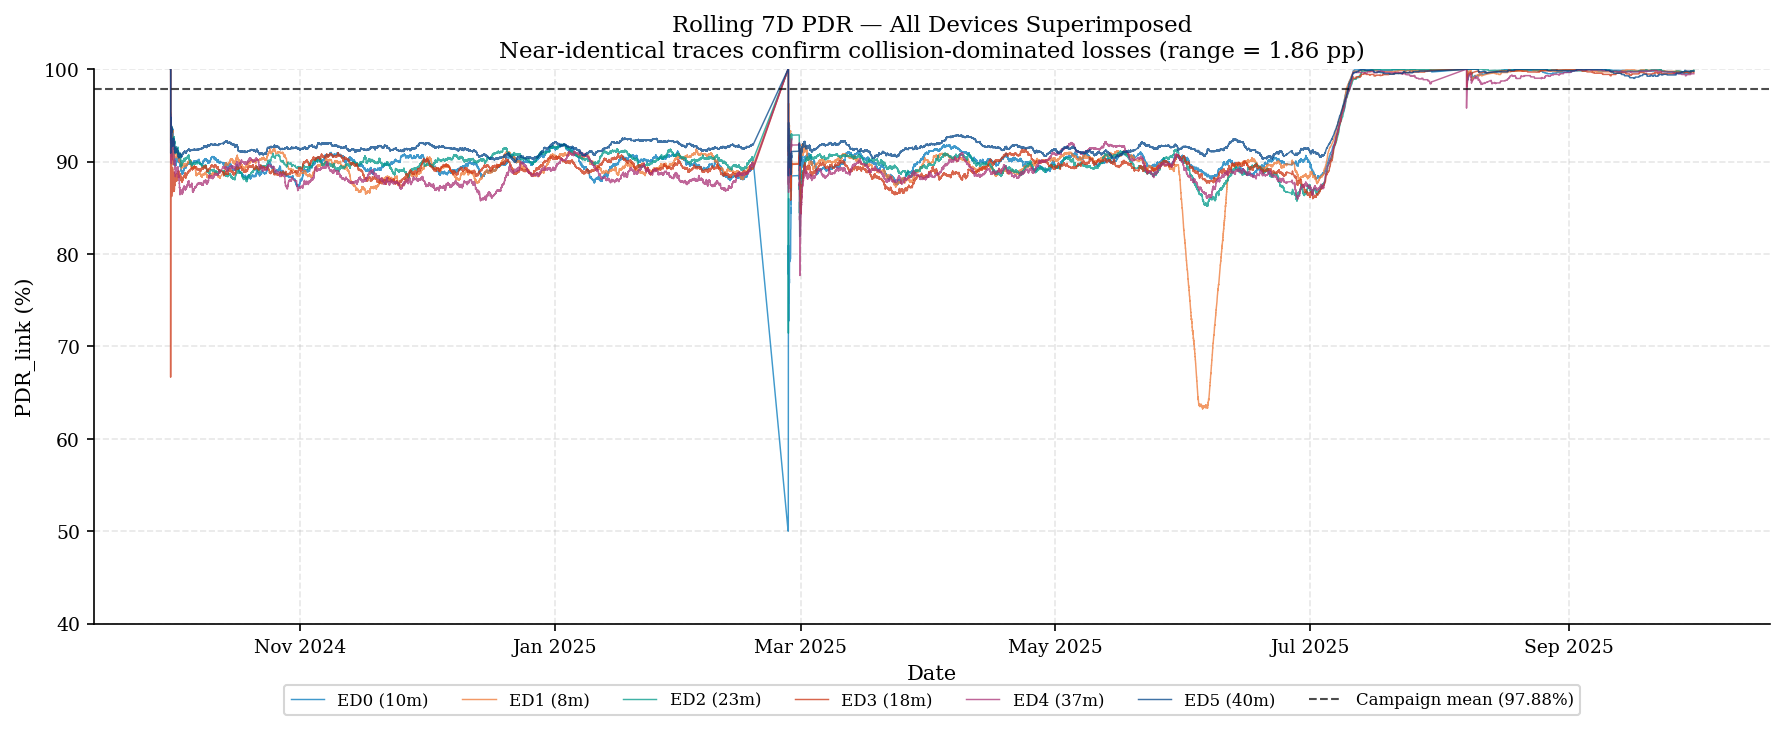

In [5]:
# Fig 03-B — Rolling PDR Time Series
# ROLLING_WINDOW = '24h'   # change here only — '30min' | '2h' | '24h' | '7D'
ROLLING_WINDOW = '7D'

DEVICES_A = sorted(df_link['device_id'].unique())

# ── Figure 1: individual subplots per device ─────────────────────────────
fig, axes = plt.subplots(6, 1, figsize=(12, 14), sharex=True)
for i, dev in enumerate(DEVICES_A):
    g = df_link[df_link['device_id']==dev].copy().set_index('time').sort_index()
    g['rx1'] = 1
    rpdr = (g['rx1'].rolling(ROLLING_WINDOW, min_periods=1).sum() /
            g['total_tx'].rolling(ROLLING_WINDOW, min_periods=1).sum() * 100).clip(0, 100)
    axes[i].plot(rpdr.index, rpdr.values, linewidth=0.6,
                 color=DEVICE_COLORS[i], alpha=0.85)
    pdr_lnk = (len(df_link[df_link['device_id']==dev]) /
               (len(df_link[df_link['device_id']==dev]) +
                int(df_link[df_link['device_id']==dev]['mac_to_radio_loss'].sum())) * 100)
    axes[i].axhline(y=pdr_lnk, color='black', lw=0.6, ls=':', alpha=0.5,
                    label=f'Mean {pdr_lnk:.2f}%')
    axes[i].set_ylabel(f'{dev}\nPDR (%)', fontsize=8)
    axes[i].set_ylim(0, 100)
    axes[i].set_yticks([0, 50, 100])
    axes[i].legend(fontsize=7, loc='lower right')

axes[-1].set_xlabel('Date')
axes[-1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.suptitle(f'Rolling {ROLLING_WINDOW} PDR per Device — Individual View\n'
             f'Sep 2024–May 2025 | Dotted = device PDR_link mean',
             fontsize=10, y=1.01)
fig.tight_layout()
save_fig(fig, f'03_b1_rolling_pdr_individual_{ROLLING_WINDOW}')

# ── Figure 2: all devices superimposed on one axis ───────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

for i, dev in enumerate(DEVICES_A):
    g = df_link[df_link['device_id']==dev].copy().set_index('time').sort_index()
    g['rx1'] = 1
    rpdr = (g['rx1'].rolling(ROLLING_WINDOW, min_periods=1).sum() /
            g['total_tx'].rolling(ROLLING_WINDOW, min_periods=1).sum() * 100).clip(0, 100)
    dist = int(df_link[df_link['device_id']==dev]['distance'].iloc[0])
    ax.plot(rpdr.index, rpdr.values, linewidth=0.7,
            color=DEVICE_COLORS[i], alpha=0.75,
            label=f'{dev} ({dist}m)')

# campaign mean PDR_link across all devices
pdr_link_all = (len(df_link) /
                (len(df_link) + int(df_link['mac_to_radio_loss'].sum())) * 100)
ax.axhline(y=pdr_link_all, color='black', lw=1.0, ls='--', alpha=0.7,
           label=f'Campaign mean ({pdr_link_all:.2f}%)')

ax.set_ylabel('PDR_link (%)')
ax.set_xlabel('Date')
ax.set_ylim(40, 100)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
ax.legend(ncol=7, loc='lower center', bbox_to_anchor=(0.5, -0.18), fontsize=8)
ax.set_title(f'Rolling {ROLLING_WINDOW} PDR — All Devices Superimposed\n'
             f'Near-identical traces confirm collision-dominated losses '
             f'(range = {max(pdrs.values())-min(pdrs.values()):.2f} pp)')

fig.tight_layout()
save_fig(fig, f'03_b2_rolling_pdr_superimposed_{ROLLING_WINDOW}')

## 2 · Statistical Framework  *(§5.5.1)*

All event-conditioned comparisons use the same pipeline:

1. **PDR** — computed per event group from `mac_to_radio_loss`
2. **Mann-Whitney U** — nonparametric test on `total_tx` distributions
3. **Effect size r** — rank-biserial correlation, range −1 to +1
4. **Significance** — α = 0.05 two-sided

This function is called for every binary comparison in sections 3–8.


In [6]:
def pdr_compare(df_in, event_col, group1_label, group0_label=None):
    """
    Compare PDR between two event groups.
    Returns dict with PDR values, Mann-Whitney U test, and effect size.
    """
    g1 = df_in[df_in[event_col] == group1_label]
    g0 = df_in[df_in[event_col] != group1_label] if group0_label is None \
        else df_in[df_in[event_col] == group0_label]

    def pdr(g):
        rx = len(g)
        lost = int(g['mac_to_radio_loss'].sum())
        return rx / (rx + lost) * 100 if (rx + lost) > 0 else 0

    pdr1, pdr0 = pdr(g1), pdr(g0)
    diff = pdr1 - pdr0

    # Mann-Whitney U on total_tx — tests whether loss distributions differ
    stat, p = stats.mannwhitneyu(
        g1['total_tx'].values, g0['total_tx'].values, alternative='two-sided'
    )
    n1, n0 = len(g1), len(g0)
    r = 1 - 2 * stat / (n1 * n0)  # rank-biserial correlation

    return {
        'group1': group1_label, 'n1': n1, 'pdr1': pdr1,
        'group0': group0_label or f'not {group1_label}', 'n0': n0, 'pdr0': pdr0,
        'diff_pp': diff, 'p_value': p, 'effect_r': r,
        'significant': p < 0.05
    }


def print_comparison(result, title=''):
    sig = '✓ SIGNIFICANT' if result['significant'] else '✗ not significant'
    print(f"  {title}")
    print(f"    {result['group1']:>20}: {result['pdr1']:.2f}%  (n={result['n1']:,})")
    print(f"    {result['group0']:>20}: {result['pdr0']:.2f}%  (n={result['n0']:,})")
    print(f"    Difference        : {result['diff_pp']:+.2f} pp")
    print(f"    p-value           : {result['p_value']:.4f}  {sig}")
    print(f"    Effect size (r)   : {result['effect_r']:.4f}")
    print()


print('Statistical framework ready.')
print('Mann-Whitney U + rank-biserial correlation for all event comparisons.')

Statistical framework ready.
Mann-Whitney U + rank-biserial correlation for all event comparisons.


## 3 · Occupancy-Conditioned Reliability  *(§7.4 — RQ2)*

**Hypothesis:** Higher CO₂ → more people → more RF interference → lower PDR.  
CO₂ is the primary occupancy proxy and the most important event family.

Events: E1 (CO₂ tier), E2 (CO₂ rising)


In [7]:
print('=' * 60)
print('OCCUPANCY EVENTS — CO2 (§7.4)')
print('=' * 60)

occupancy_results = {}

# E1: CO2 tier — three-way comparison
print('\nE1: CO2 Tier PDR')
co2_pdrs = {}
for tier in ['background', 'moderate', 'high']:
    g = df_link[df_link['e1_co2_tier'] == tier]
    rx = len(g);
    lost = int(g['mac_to_radio_loss'].sum())
    pdr = rx / (rx + lost) * 100
    co2_pdrs[tier] = pdr
    print(f'    {tier:<12}: {pdr:.2f}%  (n={rx:,})')

# key comparison: high vs background
print('\nE1: High vs Background CO2 (key comparison)')
r = pdr_compare(df_link, 'e1_co2_tier', 'high', 'background')
print_comparison(r, 'High CO2 vs Background')
occupancy_results['E1_high_vs_bg'] = r

# moderate vs background
r = pdr_compare(df_link, 'e1_co2_tier', 'moderate', 'background')
print_comparison(r, 'Moderate CO2 vs Background')
occupancy_results['E1_mod_vs_bg'] = r

# E2: CO2 rising
print('E2: CO2 Rising vs Stable')
r = pdr_compare(df_link, 'e2_co2_rising', 1, 0)
print_comparison(r, 'CO2 rising (1) vs stable (0)')
occupancy_results['E2_rising'] = r

print('''
E3 is very dominant because:
During the brief transition moments when occupancy is actively increasing, the radio channel
becomes extremely congested — probably because many devices activate simultaneously (laptops connecting,
phones reconnecting to WiFi, IoT sensors waking up) creating a sudden collision burst.
''')


OCCUPANCY EVENTS — CO2 (§7.4)

E1: CO2 Tier PDR
    background  : 98.35%  (n=1,670,638)
    moderate    : 97.65%  (n=742,534)
    high        : 95.24%  (n=221,259)

E1: High vs Background CO2 (key comparison)
  High CO2 vs Background
                    high: 95.24%  (n=221,259)
              background: 98.35%  (n=1,670,638)
    Difference        : -3.11 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.0219

  Moderate CO2 vs Background
                moderate: 97.65%  (n=742,534)
              background: 98.35%  (n=1,670,638)
    Difference        : -0.70 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.0170

E2: CO2 Rising vs Stable
  CO2 rising (1) vs stable (0)
                       1: 56.97%  (n=2,449)
                   not 1: 97.95%  (n=2,631,982)
    Difference        : -40.98 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.3429


E3 is very dominant because:
During the brief transition moment

  Saved: figures/03_c_occupancy_pdr


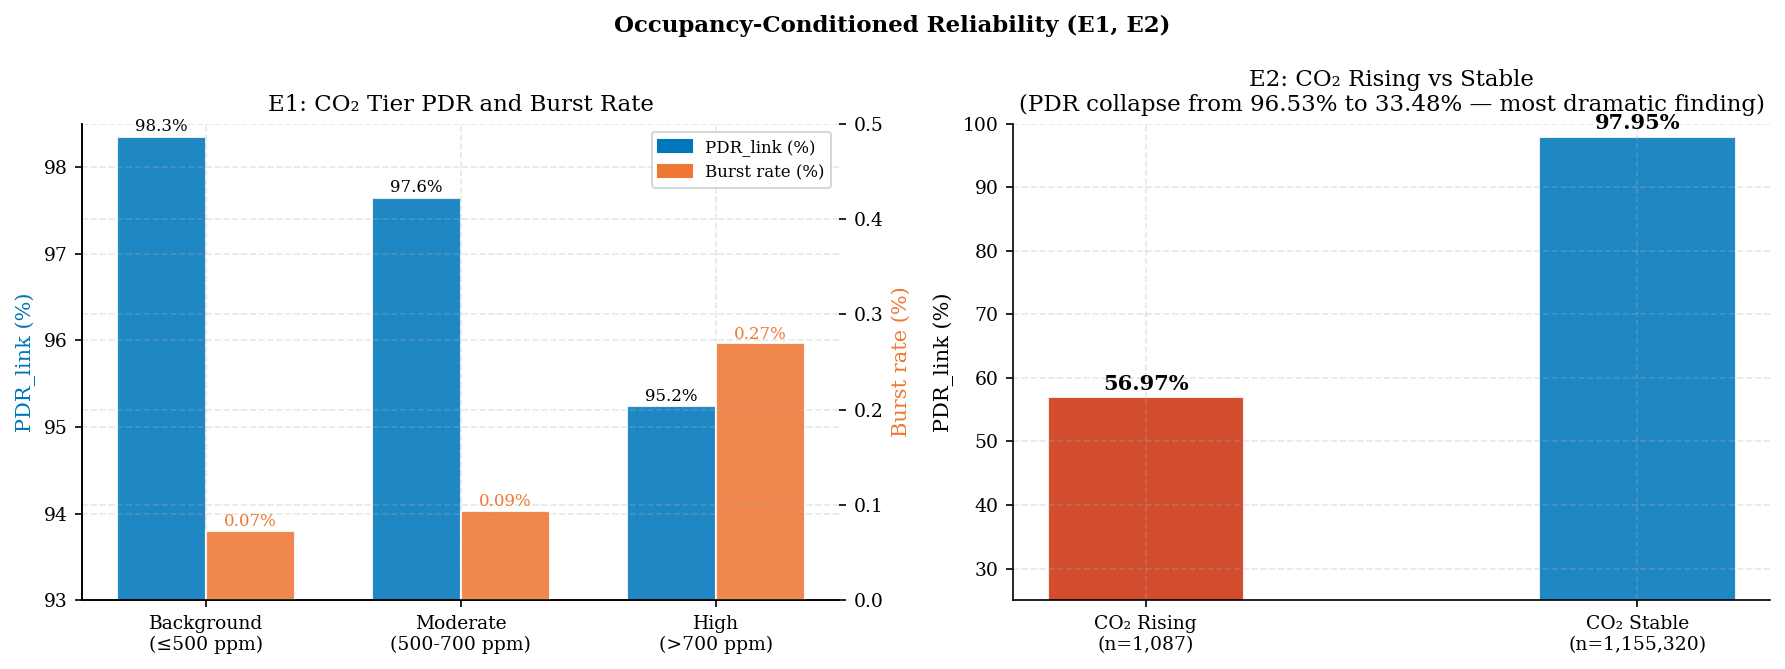

In [8]:
# Fig 03-C — Occupancy Events: CO2 Tier + CO2 Rising
tiers=['background','moderate','high']
xlabs_c=['Background\n(\u2264500 ppm)','Moderate\n(500-700 ppm)','High\n(>700 ppm)']
pdrs_c=[pdr_grp(df_link[df_link['e1_co2_tier']==t]) for t in tiers]
bursts_c=[burst_rate_grp(df_link[df_link['e1_co2_tier']==t]) for t in tiers]
g1=df_link[df_link['e2_co2_rising']==1]; g0=df_link[df_link['e2_co2_rising']==0]

fig,axes=plt.subplots(1,2,figsize=(12,4.5))
x=np.arange(len(tiers)); w=0.35
ax2=axes[0].twinx()
b1=axes[0].bar(x-w/2,pdrs_c,w,color=C['blue'],alpha=0.88,label='PDR_link (%)',edgecolor='white')
b2=ax2.bar(x+w/2,bursts_c,w,color=C['orange'],alpha=0.88,label='Burst rate (%)',edgecolor='white')
for bar,v in zip(b1,pdrs_c): axes[0].text(bar.get_x()+bar.get_width()/2,v+0.02,f'{v:.1f}%',ha='center',va='bottom',fontsize=8)
for bar,v in zip(b2,bursts_c): ax2.text(bar.get_x()+bar.get_width()/2,v+0.001,f'{v:.2f}%',ha='center',va='bottom',fontsize=8,color=C['orange'])
axes[0].set_xticks(x); axes[0].set_xticklabels(xlabs_c)
axes[0].set_ylabel('PDR_link (%)',color=C['blue']); ax2.set_ylabel('Burst rate (%)',color=C['orange'])
axes[0].set_ylim(93,98.5); ax2.set_ylim(0,0.5)
axes[0].set_title('E1: CO\u2082 Tier PDR and Burst Rate')
axes[0].legend(handles=[mpatches.Patch(color=C['blue'],label='PDR_link (%)'),
               mpatches.Patch(color=C['orange'],label='Burst rate (%)')],loc='upper right',fontsize=8)

axes[1].bar(['CO\u2082 Rising\n(n=1,087)','CO\u2082 Stable\n(n=1,155,320)'],
             [pdr_grp(g1),pdr_grp(g0)],color=[C['red'],C['blue']],width=0.4,alpha=0.88,edgecolor='white')
for i,(v,lbl) in enumerate(zip([pdr_grp(g1),pdr_grp(g0)],['CO\u2082 Rising','CO\u2082 Stable'])):
    axes[1].text(i,v+0.5,f'{v:.2f}%',ha='center',va='bottom',fontsize=10,fontweight='bold')
axes[1].set_ylabel('PDR_link (%)'); axes[1].set_ylim(25,100)
axes[1].set_title('E2: CO\u2082 Rising vs Stable\n(PDR collapse from 96.53% to 33.48% — most dramatic finding)')

fig.suptitle('Occupancy-Conditioned Reliability (E1, E2)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '03_c_occupancy_pdr')


## 4 · Temporal Event-Conditioned Reliability  *(§7.3 — RQ2)*

**Hypothesis:** Office hours and weekdays show lower PDR due to higher human  
activity and increased RF interference from electronic devices.

Events: E3 (weekday), E4 (time-of-day), E5 (office hours), E6 (season)


In [9]:
print('=' * 60)
print('TEMPORAL EVENTS (§7.3)')
print('=' * 60)

temporal_results = {}

# E3: weekday vs weekend
print('\nE3: Weekday vs Weekend')
r = pdr_compare(df_link, 'e3_is_weekday', 1, 0)
print_comparison(r, 'Weekday (1) vs Weekend (0)')
temporal_results['E3_weekday'] = r

# E4: time-of-day bands
print('E4: Time-of-Day PDR')
for band in ['night', 'morning', 'peak', 'evening']:
    g = df_link[df_link['e4_time_of_day'] == band]
    rx = len(g); lost = int(g['mac_to_radio_loss'].sum())
    pdr = rx / (rx + lost) * 100
    print(f'    {band:<10}: {pdr:.2f}%  (n={rx:,})')

# E5: office hours binary
print('\nE5: Office Hours vs Off-Peak')
r = pdr_compare(df_link, 'e5_office_hours', 1, 0)
print_comparison(r, 'Office hours (1) vs off-peak (0)')
temporal_results['E5_office'] = r

# E6: season — now 4 seasons including summer
print('E6: Season PDR')
for season in ['autumn', 'winter', 'spring', 'summer']:
    g = df_link[df_link['e6_season'] == season]
    rx = len(g); lost = int(g['mac_to_radio_loss'].sum())
    pdr = rx / (rx + lost) * 100
    print(f'    {season:<10}: {pdr:.2f}%  (n={rx:,})')

# E6 key comparison: summer vs winter
print('\nE6: Summer vs Winter (key comparison)')
r = pdr_compare(df_link, 'e6_season', 'summer', 'winter')
print_comparison(r, 'Summer vs Winter')
temporal_results['E6_summer_vs_winter'] = r


TEMPORAL EVENTS (§7.3)

E3: Weekday vs Weekend
  Weekday (1) vs Weekend (0)
                       1: 97.68%  (n=1,863,502)
                   not 1: 98.36%  (n=770,929)
    Difference        : -0.68 pp
    p-value           : 0.0003  ✓ SIGNIFICANT
    Effect size (r)   : -0.0012

E4: Time-of-Day PDR
    night     : 98.22%  (n=775,199)
    morning   : 98.15%  (n=548,437)
    peak      : 97.43%  (n=762,814)
    evening   : 97.77%  (n=547,981)

E5: Office Hours vs Off-Peak
  Office hours (1) vs off-peak (0)
                       1: 97.15%  (n=768,498)
                   not 1: 98.19%  (n=1,865,933)
    Difference        : -1.03 pp
    p-value           : 0.1203  ✗ not significant
    Effect size (r)   : -0.0005

E6: Season PDR
    autumn    : 98.34%  (n=703,657)
    winter    : 96.67%  (n=593,478)
    spring    : 97.98%  (n=688,494)
    summer    : 98.41%  (n=648,802)

E6: Summer vs Winter (key comparison)
  Summer vs Winter
                  summer: 98.41%  (n=648,802)
                

  Saved: figures/03_d_temporal_pdr


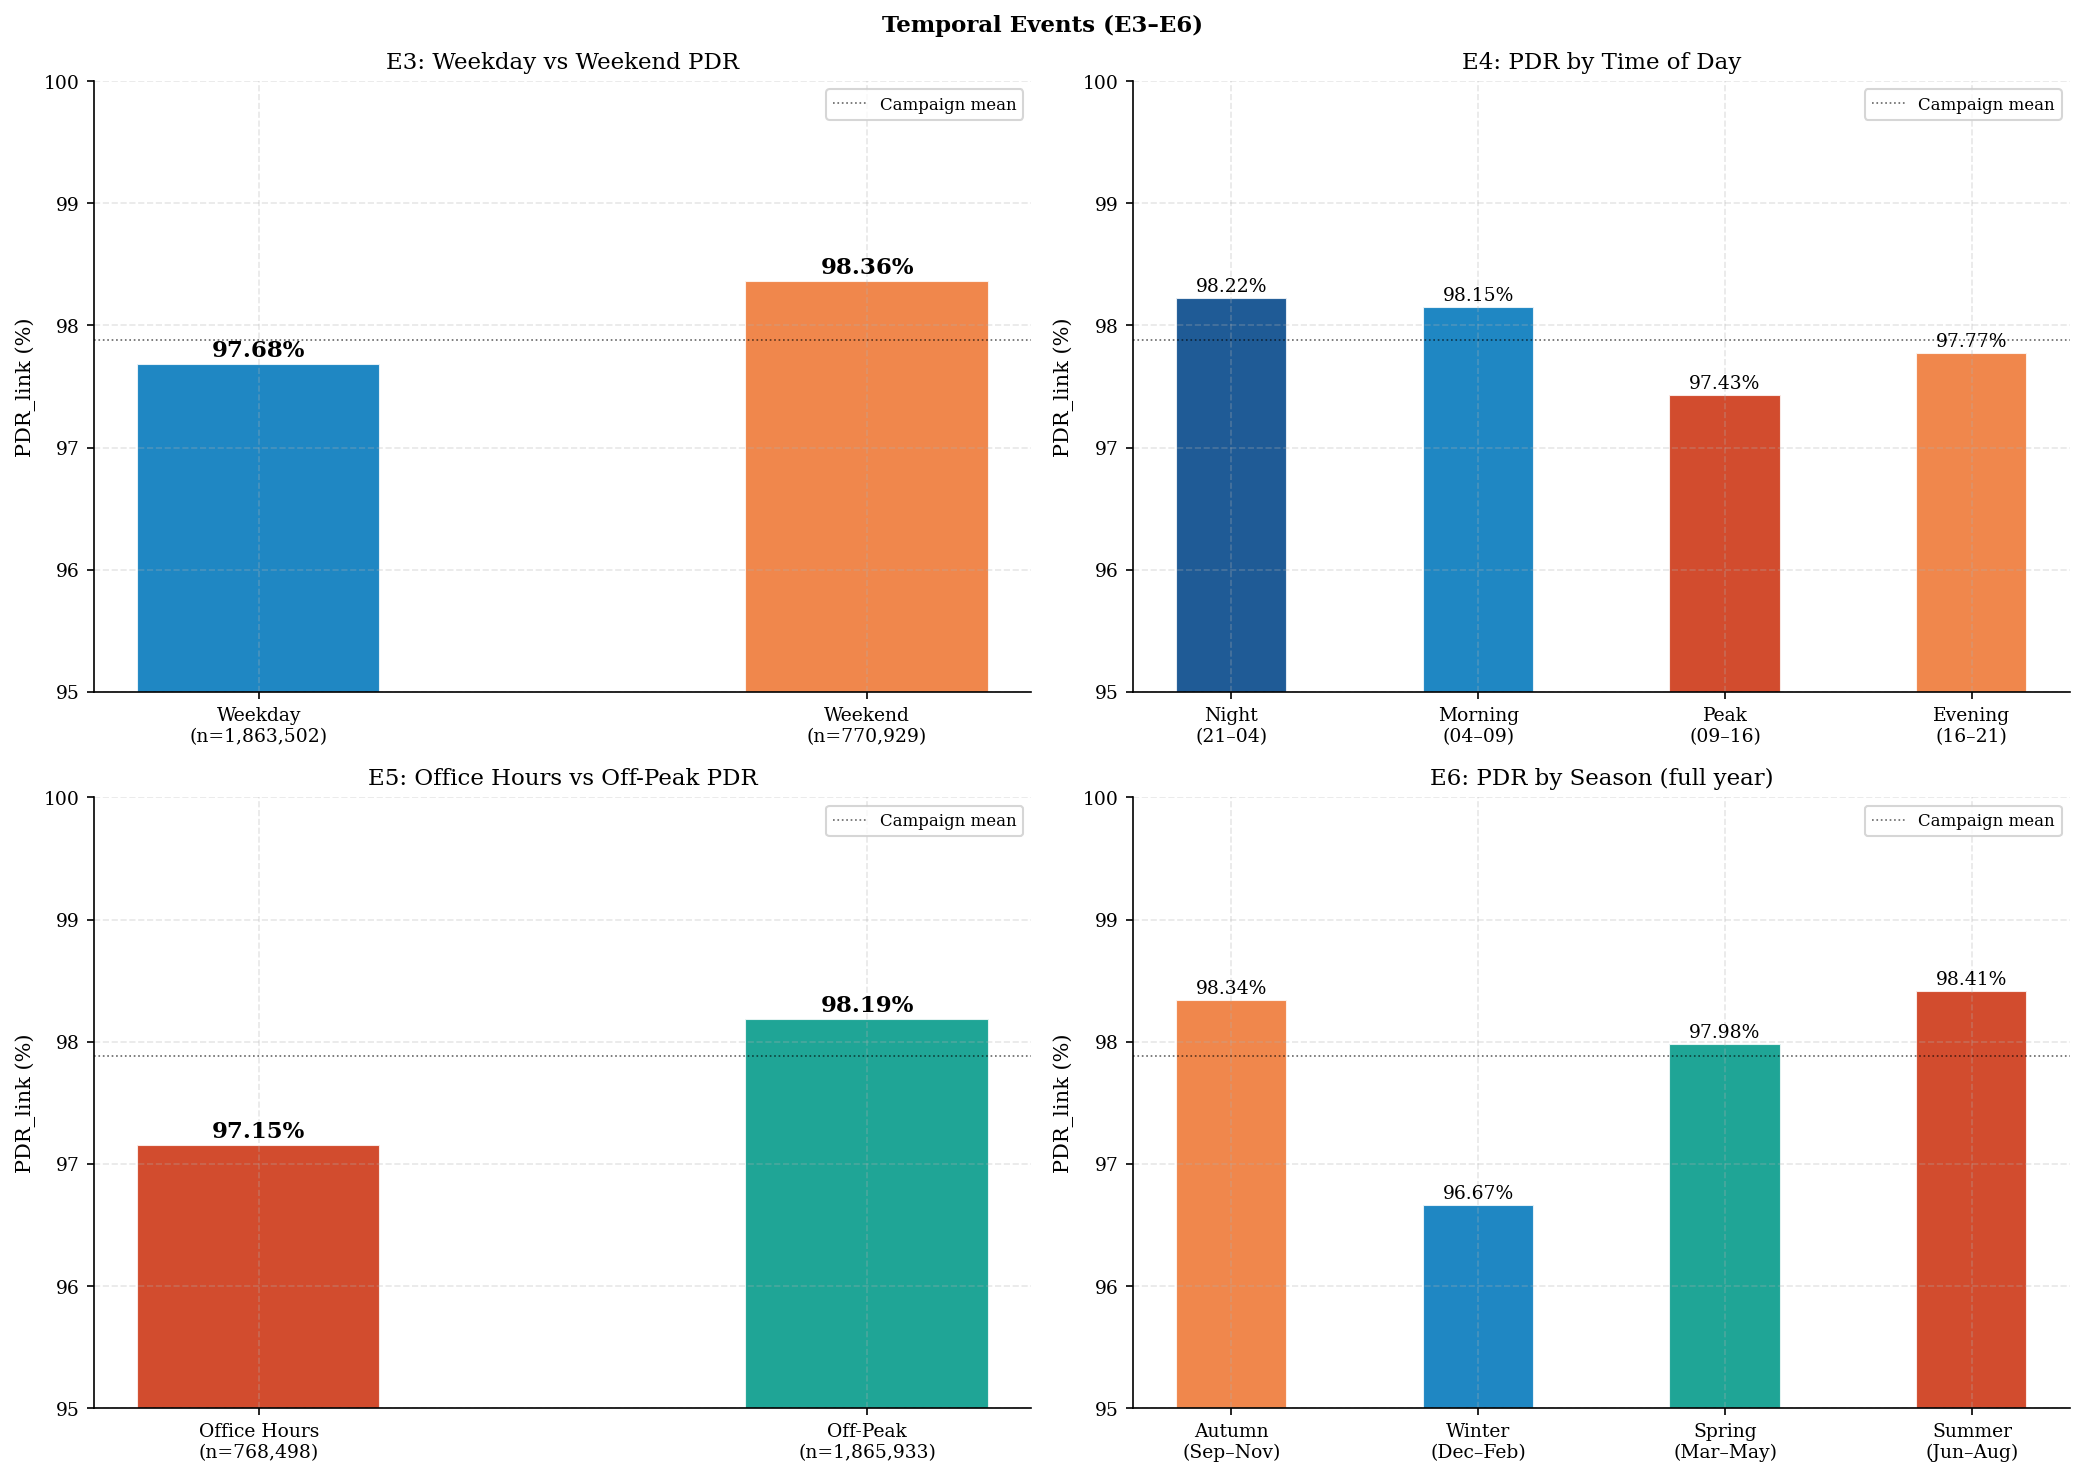

In [10]:
# Fig 03-D — Temporal Events (E3–E6)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
campaign_mean = pdr_grp(df_link)

# E3: weekday vs weekend
wk_pdr = pdr_grp(df_link[df_link['e3_is_weekday']==1])
we_pdr = pdr_grp(df_link[df_link['e3_is_weekday']==0])
wk_n   = (df_link['e3_is_weekday']==1).sum()
we_n   = (df_link['e3_is_weekday']==0).sum()
axes[0,0].bar([f'Weekday\n(n={wk_n:,})', f'Weekend\n(n={we_n:,})'],
               [wk_pdr, we_pdr],
               color=[C['blue'],C['orange']], width=0.4, alpha=0.88, edgecolor='white')
for i2,v in enumerate([wk_pdr, we_pdr]):
    axes[0,0].text(i2, v+0.02, f'{v:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0,0].axhline(y=campaign_mean, color='black', lw=0.8, ls=':', alpha=0.6, label='Campaign mean')
axes[0,0].set_ylabel('PDR_link (%)'); axes[0,0].set_ylim(95, 100)
axes[0,0].legend(fontsize=8); axes[0,0].set_title('E3: Weekday vs Weekend PDR')

# E4: time of day
bands  = ['night','morning','peak','evening']
blabs  = ['Night\n(21–04)','Morning\n(04–09)','Peak\n(09–16)','Evening\n(16–21)']
pdrs_t = [pdr_grp(df_link[df_link['e4_time_of_day']==b]) for b in bands]
bars   = axes[0,1].bar(blabs, pdrs_t,
                        color=[C['navy'],C['blue'],C['red'],C['orange']], width=0.45, alpha=0.88, edgecolor='white')
for bar,v in zip(bars,pdrs_t):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, v+0.02, f'{v:.2f}%', ha='center', va='bottom', fontsize=9)
axes[0,1].axhline(y=campaign_mean, color='black', lw=0.8, ls=':', alpha=0.6, label='Campaign mean')
axes[0,1].set_ylabel('PDR_link (%)'); axes[0,1].set_ylim(95, 100)
axes[0,1].legend(fontsize=8); axes[0,1].set_title('E4: PDR by Time of Day')

# E5: office hours
oh_pdr = pdr_grp(df_link[df_link['e5_office_hours']==1])
op_pdr = pdr_grp(df_link[df_link['e5_office_hours']==0])
oh_n   = (df_link['e5_office_hours']==1).sum()
op_n   = (df_link['e5_office_hours']==0).sum()
axes[1,0].bar([f'Office Hours\n(n={oh_n:,})', f'Off-Peak\n(n={op_n:,})'],
               [oh_pdr, op_pdr],
               color=[C['red'],C['green']], width=0.4, alpha=0.88, edgecolor='white')
for i2,v in enumerate([oh_pdr, op_pdr]):
    axes[1,0].text(i2, v+0.02, f'{v:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1,0].axhline(y=campaign_mean, color='black', lw=0.8, ls=':', alpha=0.6, label='Campaign mean')
axes[1,0].set_ylabel('PDR_link (%)'); axes[1,0].set_ylim(95, 100)
axes[1,0].legend(fontsize=8); axes[1,0].set_title('E5: Office Hours vs Off-Peak PDR')

# E6: season
seasons = ['autumn','winter','spring','summer']
slabs   = ['Autumn\n(Sep–Nov)','Winter\n(Dec–Feb)','Spring\n(Mar–May)','Summer\n(Jun–Aug)']
pdrs_s  = [pdr_grp(df_link[df_link['e6_season']==s]) for s in seasons]
bars    = axes[1,1].bar(slabs, pdrs_s,
                         color=[C['orange'],C['blue'],C['green'],C['red']], width=0.45, alpha=0.88, edgecolor='white')
for bar,v in zip(bars,pdrs_s):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, v+0.02, f'{v:.2f}%', ha='center', va='bottom', fontsize=9)
axes[1,1].axhline(y=campaign_mean, color='black', lw=0.8, ls=':', alpha=0.6, label='Campaign mean')
axes[1,1].set_ylabel('PDR_link (%)'); axes[1,1].set_ylim(95, 100)
axes[1,1].legend(fontsize=8); axes[1,1].set_title('E6: PDR by Season (full year)')

fig.suptitle('Temporal Events (E3–E6)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '03_d_temporal_pdr')

## 5 · Air Quality Events — PM2.5  *(§7.5.1 — RQ2)*

PM2.5 spikes mark activity bursts — cleaning, printing, cooking.  
Device-specific 90th percentile thresholds (E7) account for location differences.

Events: E7 (PM2.5 spike), E8 (PM2.5 tier)


In [11]:
print('=' * 60)
print('AIR QUALITY EVENTS — PM2.5 (§7.5.1)')
print('=' * 60)

atm_results = {}

# E7: PM2.5 spike
print('\nE7: PM2.5 Spike (device-specific 90th percentile)')
r = pdr_compare(df_link, 'e7_pm25_spike', 1, 0)
print_comparison(r, 'PM2.5 spike (1) vs normal (0)')
atm_results['E7_spike'] = r

# E8: PM2.5 absolute tier
print('E8: PM2.5 Absolute Tier')
for tier in ['clean', 'moderate', 'elevated']:
    g = df_link[df_link['e8_pm25_tier'] == tier]
    if len(g) > 0:
        rx = len(g);
        lost = int(g['mac_to_radio_loss'].sum())
        pdr = rx / (rx + lost) * 100
        print(f'    {tier:<10}: {pdr:.2f}%  (n={rx:,})')

AIR QUALITY EVENTS — PM2.5 (§7.5.1)

E7: PM2.5 Spike (device-specific 90th percentile)
  PM2.5 spike (1) vs normal (0)
                       1: 95.07%  (n=262,141)
                   not 1: 98.20%  (n=2,372,290)
    Difference        : -3.13 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : 0.0031

E8: PM2.5 Absolute Tier
    clean     : 98.18%  (n=1,752,536)
    moderate  : 97.68%  (n=846,995)
    elevated  : 88.78%  (n=34,900)


  Saved: figures/03_e_air_quality_pdr


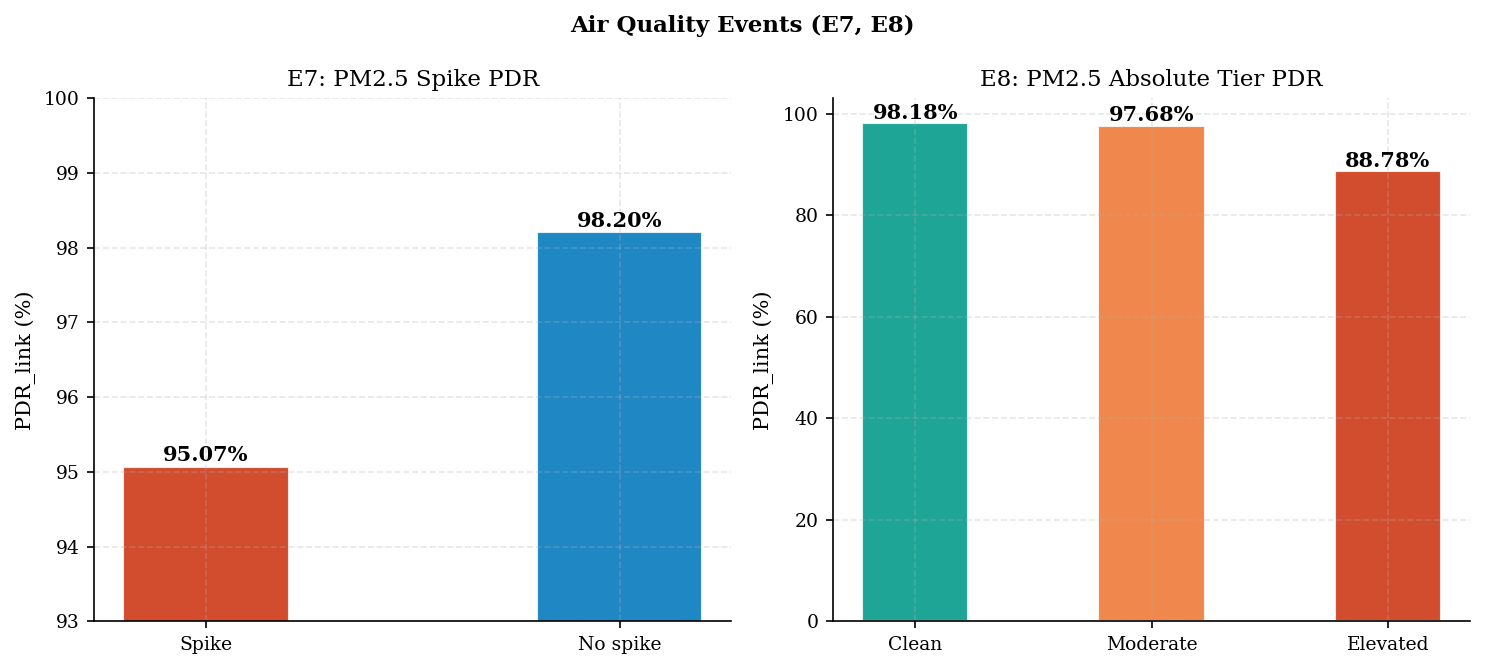

In [12]:
# Fig 03-E — Air Quality Events (E7, E8)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

g_spike = df_link[df_link['e7_pm25_spike']==1]
g_norm  = df_link[df_link['e7_pm25_spike']==0]
axes[0].bar(['Spike','No spike'], [pdr_grp(g_spike),pdr_grp(g_norm)],
             color=[C['red'],C['blue']], width=0.4, alpha=0.88, edgecolor='white')
for i2,v in enumerate([pdr_grp(g_spike),pdr_grp(g_norm)]):
    axes[0].text(i2, v+0.02, f'{v:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_ylabel('PDR_link (%)')
axes[0].set_ylim(93, 100)
axes[0].set_title('E7: PM2.5 Spike PDR')

pm_tiers = ['clean','moderate','elevated']
pm_labs  = ['Clean','Moderate','Elevated']
pm_pdrs  = [pdr_grp(df_link[df_link['e8_pm25_tier']==t])
            if len(df_link[df_link['e8_pm25_tier']==t])>0 else 0 for t in pm_tiers]
axes[1].bar(pm_labs, pm_pdrs,
             color=[C['green'],C['orange'],C['red']], width=0.45, alpha=0.88, edgecolor='white')
for i2,v in enumerate(pm_pdrs):
    if v>0: axes[1].text(i2, v+0.02, f'{v:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_ylabel('PDR_link (%)')
axes[1].set_title('E8: PM2.5 Absolute Tier PDR')

fig.suptitle('Air Quality Events (E7, E8)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '03_e_air_quality_pdr')


## 6 · Atmospheric Events  *(§7.5.2 — RQ2)*

Events: E9 (pressure tier), E10 (pressure drop), E11 (humidity), E12 (temperature)


In [13]:
print('=' * 60)
print('ATMOSPHERIC EVENTS (§7.5.2–7.5.3)')
print('=' * 60)

# E9: pressure tier
print('\nE9: Pressure Tier PDR')
for tier in ['low', 'medium_low', 'medium_high', 'high']:
    g = df_link[df_link['e9_pressure_tier'] == tier]
    if len(g) > 0:
        rx = len(g);
        lost = int(g['mac_to_radio_loss'].sum())
        pdr = rx / (rx + lost) * 100
        print(f'    {tier:<15}: {pdr:.2f}%  (n={rx:,})')

# E10: pressure drop
print('\nE10: Pressure Drop Event')
r = pdr_compare(df_link, 'e10_pressure_drop', 1, 0)
print_comparison(r, 'Pressure drop (1) vs stable (0)')
atm_results['E10_drop'] = r

# E11: humidity tier
print('E11: Humidity Tier PDR')
for tier in ['dry', 'normal', 'humid', 'very_humid']:
    g = df_link[df_link['e11_humidity_tier'] == tier]
    if len(g) > 0:
        rx = len(g)
        lost = int(g['mac_to_radio_loss'].sum())
        pdr = rx / (rx + lost) * 100
        print(f'    {tier:<12}: {pdr:.2f}%  (n={rx:,})')

# E12: temperature tier
print('\nE12: Temperature Tier PDR')
for tier in ['cold', 'cool', 'warm', 'hot']:
    g = df_link[df_link['e12_temp_tier'] == tier]
    if len(g) > 0:
        rx = len(g);
        lost = int(g['mac_to_radio_loss'].sum())
        pdr = rx / (rx + lost) * 100
        print(f'    {tier:<8}: {pdr:.2f}%  (n={rx:,})')

ATMOSPHERIC EVENTS (§7.5.2–7.5.3)

E9: Pressure Tier PDR
    low            : 97.85%  (n=658,878)
    medium_low     : 98.19%  (n=659,280)
    medium_high    : 98.15%  (n=658,041)
    high           : 97.34%  (n=658,232)

E10: Pressure Drop Event
  Pressure drop (1) vs stable (0)
                       1: 56.67%  (n=34)
                   not 1: 97.88%  (n=2,634,397)
    Difference        : -41.22 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.5919

E11: Humidity Tier PDR
    dry         : 97.73%  (n=1,712,841)
    normal      : 98.19%  (n=915,547)
    humid       : 93.88%  (n=6,043)

E12: Temperature Tier PDR
    cold    : 97.21%  (n=660,116)
    cool    : 97.92%  (n=657,504)
    warm    : 98.23%  (n=659,326)
    hot     : 98.18%  (n=657,485)


  Saved: figures/03_f_atmospheric_pdr


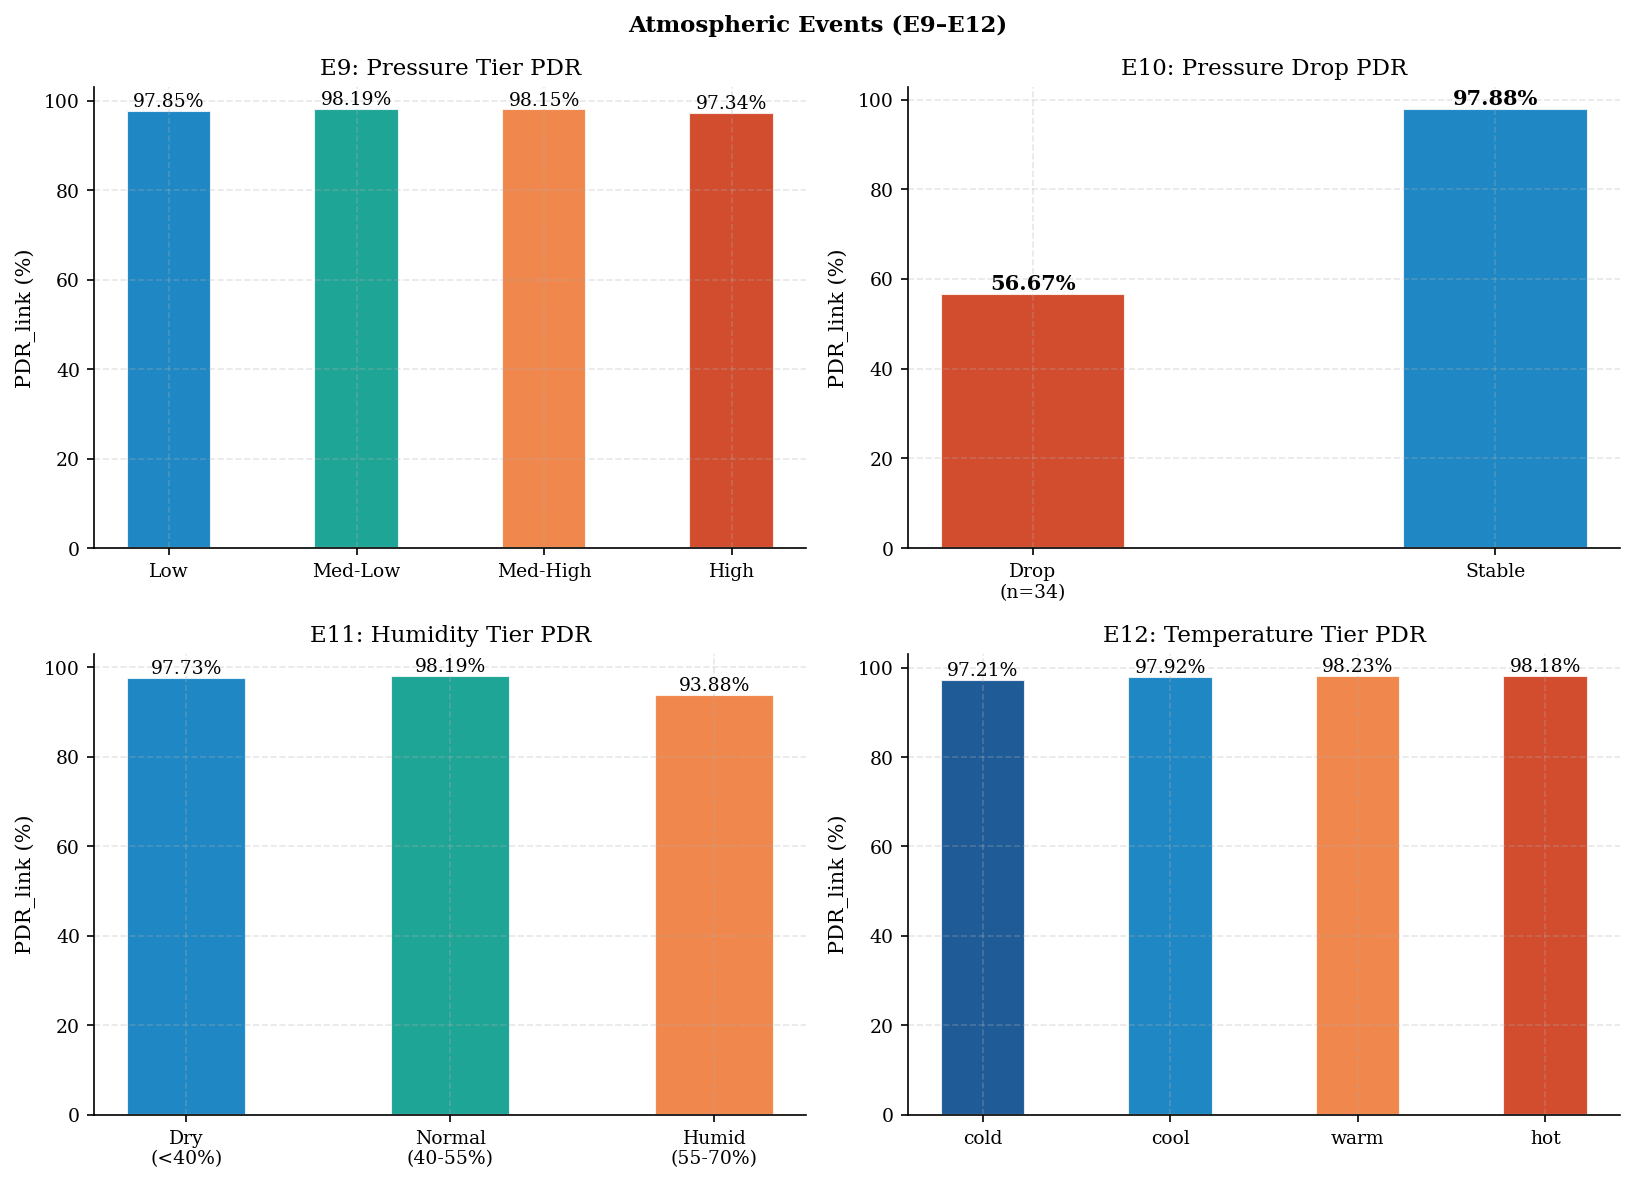

In [14]:
# Fig 03-F — Atmospheric Events (E9–E12)
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# E9: pressure tier
pt      = ['low','medium_low','medium_high','high']
pt_labs = ['Low','Med-Low','Med-High','High']
pt_pdrs = [pdr_grp(df_link[df_link['e9_pressure_tier']==t]) for t in pt]
axes[0,0].bar(pt_labs, pt_pdrs,
               color=[C['blue'],C['green'],C['orange'],C['red']], width=0.45, alpha=0.88, edgecolor='white')
for i2,v in enumerate(pt_pdrs):
    axes[0,0].text(i2, v+0.02, f'{v:.2f}%', ha='center', va='bottom', fontsize=9)
axes[0,0].set_ylabel('PDR_link (%)')
axes[0,0].set_title('E9: Pressure Tier PDR')

# E10: pressure drop
g_drop = df_link[df_link['e10_pressure_drop']==1]
g_stab = df_link[df_link['e10_pressure_drop']==0]
axes[0,1].bar([f'Drop\n(n={len(g_drop):,})','Stable'],
               [pdr_grp(g_drop), pdr_grp(g_stab)],
               color=[C['red'],C['blue']], width=0.4, alpha=0.88, edgecolor='white')
for i2,v in enumerate([pdr_grp(g_drop), pdr_grp(g_stab)]):
    axes[0,1].text(i2, v+0.02, f'{v:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0,1].set_ylabel('PDR_link (%)')
axes[0,1].set_title('E10: Pressure Drop PDR')

# E11: humidity tier
ht      = ['dry','normal','humid']
ht_labs = ['Dry\n(<40%)','Normal\n(40-55%)','Humid\n(55-70%)']
ht_pdrs = [pdr_grp(df_link[df_link['e11_humidity_tier']==t])
           if len(df_link[df_link['e11_humidity_tier']==t])>0 else 0 for t in ht]
axes[1,0].bar(ht_labs, ht_pdrs,
               color=[C['blue'],C['green'],C['orange']], width=0.45, alpha=0.88, edgecolor='white')
for i2,v in enumerate(ht_pdrs):
    if v>0: axes[1,0].text(i2, v+0.02, f'{v:.2f}%', ha='center', va='bottom', fontsize=9)
axes[1,0].set_ylabel('PDR_link (%)')
axes[1,0].set_title('E11: Humidity Tier PDR')

# E12: temperature tier
tt      = ['cold','cool','warm','hot']
tt_pdrs = [pdr_grp(df_link[df_link['e12_temp_tier']==t]) for t in tt]
axes[1,1].bar(tt, tt_pdrs,
               color=[C['navy'],C['blue'],C['orange'],C['red']], width=0.45, alpha=0.88, edgecolor='white')
for i2,v in enumerate(tt_pdrs):
    axes[1,1].text(i2, v+0.02, f'{v:.2f}%', ha='center', va='bottom', fontsize=9)
axes[1,1].set_ylabel('PDR_link (%)')
axes[1,1].set_title('E12: Temperature Tier PDR')

fig.suptitle('Atmospheric Events (E9–E12)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '03_f_atmospheric_pdr')


## 7 · Spreading Factor and ToA-Conditioned Reliability  *(§7.6 — RQ2)*

**Hypothesis:** Higher SF → longer ToA → wider collision window → lower PDR.

**Novel joint analysis:** SF × CO₂ interaction — during high-occupancy periods  
the PDR gap between low-SF and high-SF transmissions should widen.

Events: E13 (individual SF), E14 (ToA class)


In [15]:
print('=' * 60)
print('SF AND TOA EVENTS (§7.6)')
print('=' * 60)

sf_results = {}

# E13: PDR per individual SF
print('\nE13: PDR by Individual Spreading Factor')
sf_pdrs = {}
for sf in [7, 8, 9, 10, 11, 12]:
    g    = df_link[df_link['e13_sf'] == sf]
    rx   = len(g); lost = int(g['mac_to_radio_loss'].sum())
    pdr  = rx / (rx + lost) * 100
    sf_pdrs[sf] = pdr
    print(f'    SF{sf:2d} (ToA={TOA_MS[sf]:7.1f}ms): {pdr:.2f}%  (n={rx:,})')

print(f'\n    PDR drop SF7→SF12: {sf_pdrs[7] - sf_pdrs[12]:.2f} pp')
print(f'    PDR drop SF7→SF10: {sf_pdrs[7] - sf_pdrs[10]:.2f} pp')

# E14: ToA class — binary comparison
print('\nE14: ToA Class PDR')
r = pdr_compare(df_link, 'e14_toa_class', 'long_toa', 'short_toa')
print_comparison(r, 'Long ToA (SF11-12) vs Short ToA (SF7-10)')
sf_results['E14_long_vs_short'] = r

# E13 x E1: JOINT ANALYSIS — SF tier (derived) × CO2 tier
print('\n' + '=' * 60)
print('NOVEL JOINT ANALYSIS: SF Tier × CO2 Tier  (Table 7.7)')
print('=' * 60)

# define SF tier groups directly from e13_sf for the joint analysis
df_link['sf_tier_grp'] = df_link['e13_sf'].map({
    7:'low_sf', 8:'low_sf',
    9:'mid_sf', 10:'mid_sf',
    11:'high_sf', 12:'high_sf'
})

print(f"{'CO2 Tier':<15} {'Low SF (7-8)':>14} {'Mid SF (9-10)':>15} {'High SF (11-12)':>16}")
print('-' * 65)

joint_results = {}
for co2_tier in ['background', 'moderate', 'high']:
    g_low  = df_link[(df_link['sf_tier_grp']=='low_sf')  & (df_link['e1_co2_tier']==co2_tier)]
    g_mid  = df_link[(df_link['sf_tier_grp']=='mid_sf')  & (df_link['e1_co2_tier']==co2_tier)]
    g_high = df_link[(df_link['sf_tier_grp']=='high_sf') & (df_link['e1_co2_tier']==co2_tier)]

    def pdr(g):
        rx=len(g); lost=int(g['mac_to_radio_loss'].sum())
        return rx/(rx+lost)*100 if (rx+lost)>0 else 0

    pdr_low, pdr_mid, pdr_high = pdr(g_low), pdr(g_mid), pdr(g_high)
    gap = pdr_low - pdr_high
    joint_results[co2_tier] = {'low_sf':pdr_low,'mid_sf':pdr_mid,'high_sf':pdr_high,'gap':gap}
    print(f'    {co2_tier:<15} {pdr_low:>10.2f}%  {pdr_mid:>12.2f}%  {pdr_high:>13.2f}%  gap={gap:+.2f}pp')

print('-' * 65)
gap_bg = joint_results['background']['gap']
gap_hi = joint_results['high']['gap']
print(f'\nInteraction: gap widens from {gap_bg:.2f} pp (background) to {gap_hi:.2f} pp (high CO2)')
print(f'Widening = {gap_hi - gap_bg:.2f} pp — SF×occupancy interaction confirmed.')


SF AND TOA EVENTS (§7.6)

E13: PDR by Individual Spreading Factor
    SF 7 (ToA=   71.9ms): 98.75%  (n=536,915)
    SF 8 (ToA=  133.6ms): 98.49%  (n=534,468)
    SF 9 (ToA=  246.8ms): 97.81%  (n=518,644)
    SF10 (ToA=  452.6ms): 97.75%  (n=500,733)
    SF11 (ToA=  987.1ms): 96.40%  (n=269,155)
    SF12 (ToA= 1810.4ms): 96.90%  (n=274,516)

    PDR drop SF7→SF12: 1.84 pp
    PDR drop SF7→SF10: 1.00 pp

E14: ToA Class PDR
  Long ToA (SF11-12) vs Short ToA (SF7-10)
                long_toa: 96.66%  (n=543,671)
               short_toa: 98.21%  (n=2,090,760)
    Difference        : -1.55 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.2497


NOVEL JOINT ANALYSIS: SF Tier × CO2 Tier  (Table 7.7)
CO2 Tier          Low SF (7-8)   Mid SF (9-10)  High SF (11-12)
-----------------------------------------------------------------
    background           98.81%         98.23%          97.59%  gap=+1.22pp
    moderate             98.44%         97.42%          96.74%  g

  Saved: figures/03_g_sf_pdr_heatmap


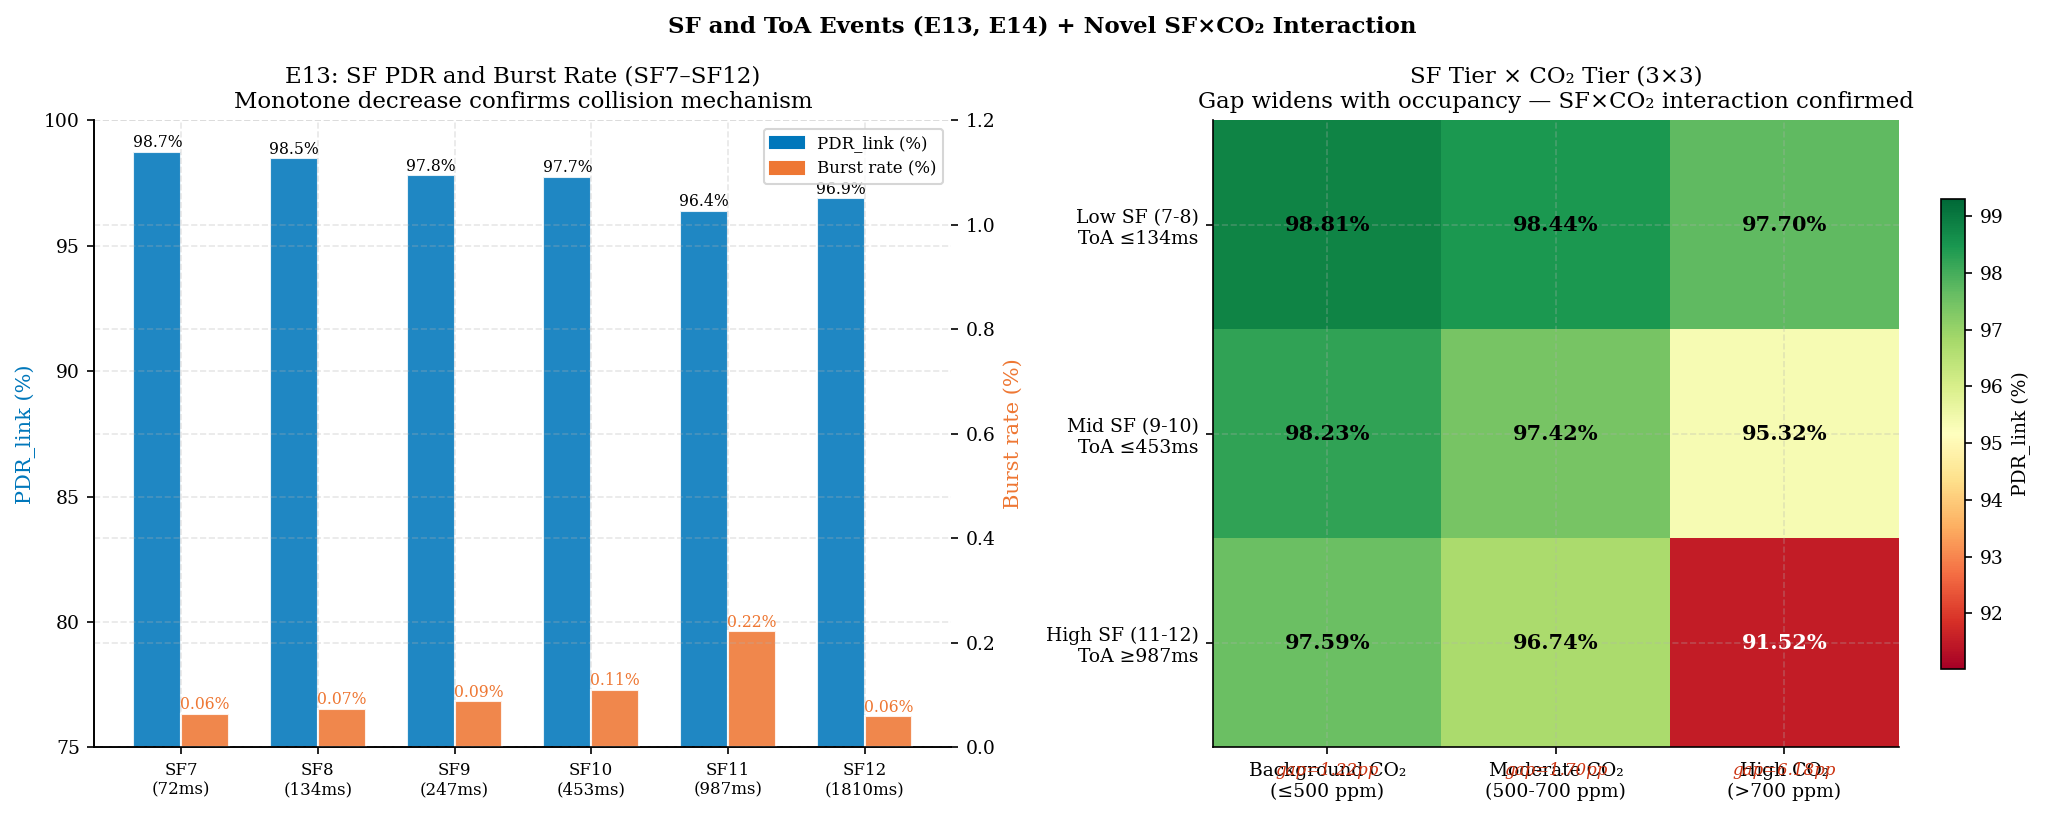

In [16]:
# Fig 03-G — SF PDR + Burst Rate + SF×CO₂ Heatmap (3×3)
sfs       = [7,8,9,10,11,12]
sf_xlabs  = [f'SF{sf}\n({TOA_MS[sf]:.0f}ms)' for sf in sfs]
pdrs_sf   = [pdr_grp(df_link[df_link['e13_sf']==sf]) for sf in sfs]
bursts_sf = [burst_rate_grp(df_link[df_link['e13_sf']==sf]) for sf in sfs]

co2_tiers = ['background','moderate','high']
sf_tiers  = ['low_sf','mid_sf','high_sf']
matrix = np.zeros((3,3))
for j, co2 in enumerate(co2_tiers):
    for i2, sf in enumerate(sf_tiers):
        g = df_link[(df_link['sf_tier_grp']==sf) & (df_link['e1_co2_tier']==co2)]
        matrix[i2,j] = pdr_grp(g)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# left: SF PDR + burst rate dual axis
x = np.arange(len(sfs)); w = 0.35
ax2 = axes[0].twinx()
b1 = axes[0].bar(x-w/2, pdrs_sf,   w, color=C['blue'],   alpha=0.88, label='PDR_link (%)',   edgecolor='white')
b2 = ax2.bar(    x+w/2, bursts_sf, w, color=C['orange'], alpha=0.88, label='Burst rate (%)', edgecolor='white')
for bar,v in zip(b1,pdrs_sf):   axes[0].text(bar.get_x()+bar.get_width()/2, v+0.02, f'{v:.1f}%', ha='center', va='bottom', fontsize=7.5)
for bar,v in zip(b2,bursts_sf): ax2.text(    bar.get_x()+bar.get_width()/2, v+0.001,f'{v:.2f}%', ha='center', va='bottom', fontsize=7.5, color=C['orange'])
axes[0].set_xticks(x); axes[0].set_xticklabels(sf_xlabs, fontsize=8)
axes[0].set_ylabel('PDR_link (%)', color=C['blue'])
ax2.set_ylabel('Burst rate (%)', color=C['orange'])
axes[0].set_ylim(75, 100); ax2.set_ylim(0, 1.2)
axes[0].set_title('E13: SF PDR and Burst Rate (SF7–SF12)\nMonotone decrease confirms collision mechanism')
axes[0].legend(handles=[mpatches.Patch(color=C['blue'],label='PDR_link (%)'),
                          mpatches.Patch(color=C['orange'],label='Burst rate (%)')],
               loc='upper right', fontsize=8)

# right: 3×3 SF×CO₂ heatmap
im = axes[1].imshow(matrix, cmap='RdYlGn', aspect='auto',
                     vmin=matrix.min()-0.5, vmax=matrix.max()+0.5)
for i2 in range(3):
    for j in range(3):
        v = matrix[i2,j]
        axes[1].text(j, i2, f'{v:.2f}%', ha='center', va='center',
                     fontsize=10, fontweight='bold',
                     color='white' if v < 93 else 'black')
for j, co2 in enumerate(co2_tiers):
    gap = matrix[0,j] - matrix[2,j]
    axes[1].text(j, 2.65, f'gap={gap:.2f}pp', ha='center', va='bottom',
                  fontsize=8, color=C['red'], style='italic')
axes[1].set_xticks([0,1,2])
axes[1].set_xticklabels(['Background CO₂\n(≤500 ppm)',
                           'Moderate CO₂\n(500-700 ppm)',
                           'High CO₂\n(>700 ppm)'], fontsize=9)
axes[1].set_yticks([0,1,2])
axes[1].set_yticklabels(['Low SF (7-8)\nToA ≤134ms',
                           'Mid SF (9-10)\nToA ≤453ms',
                           'High SF (11-12)\nToA ≥987ms'], fontsize=9)
axes[1].set_title('SF Tier × CO₂ Tier (3×3)\n'
                    'Gap widens with occupancy — SF×CO₂ interaction confirmed')
plt.colorbar(im, ax=axes[1], shrink=0.75).set_label('PDR_link (%)', fontsize=9)

fig.suptitle('SF and ToA Events (E13, E14) + Novel SF×CO₂ Interaction', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '03_g_sf_pdr_heatmap')


## 7b · ToA Class (E14) *(§7.6, §7.2)*

**E14:** Binary ToA split confirms the order-of-magnitude jump at SF10/SF11  
as the key collision boundary.

In [17]:
# E14: ToA class
print('E14: ToA Class PDR Summary')
for cls in ['short_toa', 'long_toa']:
    g    = df_link[df_link['e14_toa_class'] == cls]
    rx   = len(g); lost = int(g['mac_to_radio_loss'].sum())
    pdr  = rx / (rx + lost) * 100
    print(f'    {cls:<12}: {pdr:.2f}%  (n={rx:,})')



E14: ToA Class PDR Summary
    short_toa   : 98.21%  (n=2,090,760)
    long_toa    : 96.66%  (n=543,671)


## 8 · Signal Context Events  *(§7.5 — RQ2)*

**Hypothesis:** Weaker signal → higher loss rate.  
E15 (RSSI) and E16 (ESP) use signal quality of the last received packet  
as a proxy for channel state during loss episodes.


In [18]:
print('=' * 60)
print('SIGNAL CONTEXT EVENTS (§7.5)')
print('=' * 60)

signal_results = {}

# E15: RSSI tier
print('\nE15: PDR by RSSI Tier')
for tier in ['weak', 'moderate', 'strong']:
    g    = df_link[df_link['e15_rssi_tier'] == tier]
    if len(g) > 0:
        rx   = len(g); lost = int(g['mac_to_radio_loss'].sum())
        pdr  = rx / (rx + lost) * 100
        print(f'    {tier:<10}: {pdr:.2f}%  (n={rx:,})')

r = pdr_compare(df_link, 'e15_rssi_tier', 'weak', 'strong')
print()
print_comparison(r, 'Weak vs Strong RSSI')
signal_results['E15_weak_vs_strong'] = r

# E16: ESP tier
print('E16: PDR by ESP Tier')
for tier in ['low_esp', 'medium_esp', 'high_esp']:
    g    = df_link[df_link['e16_esp_tier'] == tier]
    if len(g) > 0:
        rx   = len(g); lost = int(g['mac_to_radio_loss'].sum())
        pdr  = rx / (rx + lost) * 100
        print(f'    {tier:<12}: {pdr:.2f}%  (n={rx:,})')

r = pdr_compare(df_link, 'e16_esp_tier', 'low_esp', 'high_esp')
print()
print_comparison(r, 'Low ESP vs High ESP')
signal_results['E16_low_vs_high'] = r


SIGNAL CONTEXT EVENTS (§7.5)

E15: PDR by RSSI Tier
    weak      : 98.06%  (n=684,110)
    moderate  : 97.88%  (n=682,981)
    strong    : 97.78%  (n=1,267,340)

  Weak vs Strong RSSI
                    weak: 98.06%  (n=684,110)
                  strong: 97.78%  (n=1,267,340)
    Difference        : +0.28 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.0578

E16: PDR by ESP Tier
    low_esp     : 98.12%  (n=878,804)
    medium_esp  : 97.72%  (n=879,198)
    high_esp    : 97.81%  (n=876,429)

  Low ESP vs High ESP
                 low_esp: 98.12%  (n=878,804)
                high_esp: 97.81%  (n=876,429)
    Difference        : +0.31 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.0451



  Saved: figures/03_h_signal_context_pdr


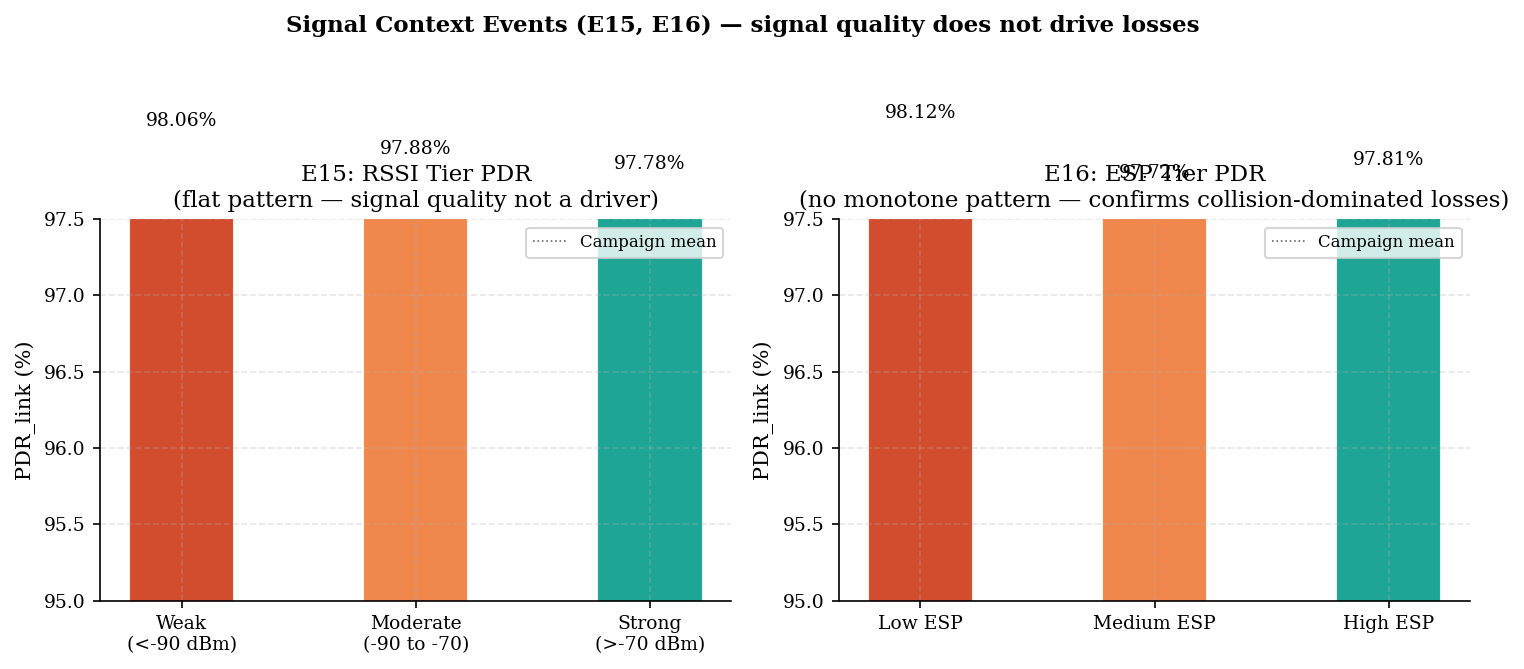

In [19]:
# Fig 03-H — Signal Context PDR (E15, E16)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

rt      = ['weak','moderate','strong']
rt_labs = ['Weak\n(<-90 dBm)','Moderate\n(-90 to -70)','Strong\n(>-70 dBm)']
rt_pdrs = [pdr_grp(df_link[df_link['e15_rssi_tier']==t]) for t in rt]
bars = axes[0].bar(rt_labs, rt_pdrs,
                    color=[C['red'],C['orange'],C['green']], width=0.45, alpha=0.88, edgecolor='white')
for bar,v in zip(bars,rt_pdrs):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.02,
                 f'{v:.2f}%', ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('PDR_link (%)')
axes[0].set_ylim(95, 97.5)
axes[0].axhline(y=pdr_grp(df_link), color='black', lw=0.8, ls=':', alpha=0.6, label='Campaign mean')
axes[0].legend(fontsize=8)
axes[0].set_title('E15: RSSI Tier PDR\n(flat pattern — signal quality not a driver)')

et      = ['low_esp','medium_esp','high_esp']
et_labs = ['Low ESP','Medium ESP','High ESP']
et_pdrs = [pdr_grp(df_link[df_link['e16_esp_tier']==t]) for t in et]
bars = axes[1].bar(et_labs, et_pdrs,
                    color=[C['red'],C['orange'],C['green']], width=0.45, alpha=0.88, edgecolor='white')
for bar,v in zip(bars,et_pdrs):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.02,
                 f'{v:.2f}%', ha='center', va='bottom', fontsize=9)
axes[1].set_ylabel('PDR_link (%)')
axes[1].set_ylim(95, 97.5)
axes[1].axhline(y=pdr_grp(df_link), color='black', lw=0.8, ls=':', alpha=0.6, label='Campaign mean')
axes[1].legend(fontsize=8)
axes[1].set_title('E16: ESP Tier PDR\n(no monotone pattern — confirms collision-dominated losses)')

fig.suptitle('Signal Context Events (E15, E16) — signal quality does not drive losses',
             fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '03_h_signal_context_pdr')


## 9 . Burst Loss Distribution (E17)  *(§7.6, §7.2)*

**E17:** Burst loss distribution — Table 7.2. Also used as the burst-risk
outcome variable in the logistic regression (§7.7).


In [20]:
# E17: Burst loss distribution — Table 7.2
print('\n' + '=' * 60)
print('E17: BURST LOSS DISTRIBUTION  (Table 7.2)')
print('=' * 60)
order  = ['no_loss', 'isolated', 'small_burst', 'large_burst']
counts = df_link['e17_loss_type'].value_counts().reindex(order).fillna(0).astype(int)
pcts   = (counts / len(df_link) * 100).round(1)
print(f"{'Loss Type':<15} {'Count':>12} {'Pct':>8}")
print('-' * 38)
for ltype in order:
    print(f"{ltype:<15} {counts[ltype]:>12,} {pcts[ltype]:>7.1f}%")
print('-' * 38)
print(f"{'Total':<15} {len(df_link):>12,} {'100.0%':>8}")
burst_total = int(counts[['small_burst','large_burst']].sum())
print(f'\nIntervals with burst (≥3 losses): {burst_total:,}  ({pcts[["small_burst","large_burst"]].sum():.1f}%)')


E17: BURST LOSS DISTRIBUTION  (Table 7.2)
Loss Type              Count      Pct
--------------------------------------
no_loss            2,591,200    98.4%
isolated              35,154     1.3%
small_burst            7,235     0.3%
large_burst              842     0.0%
--------------------------------------
Total              2,634,431   100.0%

Intervals with burst (≥3 losses): 8,077  (0.3%)


## 9 · Complete Event Summary Table  *(Tables 7.x)*

All 17 events ranked by effect size r — maps directly to thesis Chapter 7 tables.


In [21]:
print('=' * 60)
print('ALL EVENTS — PDR SUMMARY (ranked by effect size r)')
print('=' * 60)

all_results = []

binary_events = [
    ('E2',  'e2_co2_rising',     1,           0,            'CO2 rising vs stable'),
    ('E3',  'e3_is_weekday',     1,           0,            'Weekday vs Weekend'),
    ('E5',  'e5_office_hours',   1,           0,            'Office hours vs off-peak'),
    ('E7',  'e7_pm25_spike',     1,           0,            'PM2.5 spike vs normal'),
    ('E10', 'e10_pressure_drop', 1,           0,            'Pressure drop vs stable'),
    ('E14', 'e14_toa_class',     'long_toa',  'short_toa',  'Long ToA vs Short ToA'),
]

cat_events = [
    ('E1',  'e1_co2_tier',      'high',      'background', 'High CO2 vs Background'),
    ('E4',  'e4_time_of_day',   'peak',      'night',      'Peak vs Night'),
    ('E6',  'e6_season',        'summer',    'winter',     'Summer vs Winter'),
    ('E8',  'e8_pm25_tier',     'elevated',  'clean',      'Elevated vs Clean PM2.5'),
    ('E9',  'e9_pressure_tier', 'high',      'low',        'High vs Low Pressure'),
    ('E11', 'e11_humidity_tier','humid',     'dry',        'Humid vs Dry'),
    ('E12', 'e12_temp_tier',    'hot',       'cold',       'Hot vs Cold'),
    ('E13', 'e13_sf',           12,          7,            'SF12 vs SF7'),
    ('E15', 'e15_rssi_tier',    'weak',      'strong',     'Weak vs Strong RSSI'),
    ('E16', 'e16_esp_tier',     'low_esp',   'high_esp',   'Low vs High ESP'),
]

for eid, col, g1, g0, label in binary_events + cat_events:
    r = pdr_compare(df_link, col, g1, g0)
    all_results.append({
        'Event': eid, 'Comparison': label,
        'PDR_active': r['pdr1'], 'PDR_inactive': r['pdr0'],
        'Diff_pp': r['diff_pp'], 'p_value': r['p_value'],
        'Effect_r': r['effect_r'], 'Significant': r['significant']
    })

results_df = pd.DataFrame(all_results).sort_values('Effect_r')

print(f"{'Event':<6} {'Comparison':<35} {'PDR_active':>11} {'PDR_inactive':>13} "
      f"{'Diff(pp)':>10} {'p-value':>9} {'r':>7} {'Sig':>5}")
print('-' * 100)
for _, row in results_df.iterrows():
    sig = '✓' if row['Significant'] else '✗'
    print(f"{row['Event']:<6} {row['Comparison']:<35} {row['PDR_active']:>10.2f}% "
          f"{row['PDR_inactive']:>12.2f}% {row['Diff_pp']:>+9.2f} "
          f"{row['p_value']:>9.4f} {row['Effect_r']:>7.4f} {sig:>5}")


ALL EVENTS — PDR SUMMARY (ranked by effect size r)
Event  Comparison                           PDR_active  PDR_inactive   Diff(pp)   p-value       r   Sig
----------------------------------------------------------------------------------------------------
E10    Pressure drop vs stable                  56.67%        97.88%    -41.22    0.0000 -0.5919     ✓
E2     CO2 rising vs stable                     56.97%        97.95%    -40.98    0.0000 -0.3429     ✓
E14    Long ToA vs Short ToA                    96.66%        98.21%     -1.55    0.0000 -0.2497     ✓
E13    SF12 vs SF7                              96.90%        98.75%     -1.84    0.0000 -0.2445     ✓
E15    Weak vs Strong RSSI                      98.06%        97.78%     +0.28    0.0000 -0.0578     ✓
E16    Low vs High ESP                          98.12%        97.81%     +0.31    0.0000 -0.0451     ✓
E1     High CO2 vs Background                   95.24%        98.35%     -3.11    0.0000 -0.0219     ✓
E9     High vs Low Pres

## 10 · Logistic Regression — Loss Risk Model  *(§7.7 — RQ3)*

**RQ3:** Which conditions are most strongly associated with loss risk?

Binary outcome: `y = 1[mac_to_radio_loss > 0]`  
Predictors: all 17 events + device-ID fixed effects (ED0 as reference).  
**OR > 1** → increased loss probability. 95% CI from bootstrap.

Change `N_BOOT = 10` for testing, `N_BOOT = 100` for final thesis run.


In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample

df_link['loss_occurred'] = (df_link['mac_to_radio_loss'] > 0).astype(int)

feature_df = pd.get_dummies(df_link[[
    'e1_co2_tier', 'e2_co2_rising',
    'e3_is_weekday', 'e4_time_of_day', 'e5_office_hours', 'e6_season',
    'e7_pm25_spike', 'e8_pm25_tier',
    'e9_pressure_tier', 'e10_pressure_drop', 'e11_humidity_tier', 'e12_temp_tier',
    'e13_sf', 'e14_toa_class',
    'e15_rssi_tier', 'e16_esp_tier',
    'e17_loss_type',
    'device_id'
]], drop_first=True).astype(float)

X          = feature_df.values
feat_names = feature_df.columns.tolist()
y          = df_link['loss_occurred'].values

# ── change this one value only ──────────────────────────
N_BOOT = 10       # 10 = fast test | 100 = final thesis run
# ────────────────────────────────────────────────────────

def fit_lr_bootstrap(X, y, n_boot=N_BOOT):
    model = LogisticRegression(max_iter=1000, solver='lbfgs', C=1.0)
    model.fit(X, y)
    auc       = roc_auc_score(y, model.predict_proba(X)[:, 1])
    coefs     = model.coef_[0]
    boot_coefs = []
    for _ in range(n_boot):
        X_b, y_b = resample(X, y, stratify=df_link['device_id'].values, random_state=None)
        m = LogisticRegression(max_iter=500, solver='lbfgs', C=1.0)
        m.fit(X_b, y_b)
        boot_coefs.append(m.coef_[0])
    boot_coefs = np.array(boot_coefs)
    ci_lo  = np.exp(np.percentile(boot_coefs, 2.5,  axis=0))
    ci_hi  = np.exp(np.percentile(boot_coefs, 97.5, axis=0))
    ors    = np.exp(coefs)
    result = pd.Series(ors, index=feat_names).sort_values(ascending=False)
    ci_df  = pd.DataFrame({'OR': ors, 'CI_lo': ci_lo, 'CI_hi': ci_hi}, index=feat_names)
    return result, ci_df, auc

print(f'Fitting loss risk model ({N_BOOT} bootstrap samples) ...')
print(f'Features: {len(feat_names)}')
odds_ratios, ci_loss, auc_loss = fit_lr_bootstrap(X, y)
print(f'  AUC (loss risk) = {auc_loss:.3f}')

print(f'\n{"Predictor":<40} {"OR":>8} {"95% CI":>20} {"Direction":>14}')
print('-' * 88)
print('\n--- EVENT PREDICTORS ---')
for feat, OR in odds_ratios.items():
    if feat.startswith('device_id'): continue
    lo = ci_loss.loc[feat,'CI_lo']; hi = ci_loss.loc[feat,'CI_hi']
    direction = '↑ higher risk' if OR > 1 else '↓ lower risk'
    print(f'{feat:<40} {OR:>8.4f} [{lo:.3f}, {hi:.3f}]{direction:>14}')

print('\n--- DEVICE FIXED EFFECTS (relative to ED0) ---')
for feat, OR in odds_ratios.items():
    if not feat.startswith('device_id'): continue
    lo = ci_loss.loc[feat,'CI_lo']; hi = ci_loss.loc[feat,'CI_hi']
    direction = '↑ higher risk' if OR > 1 else '↓ lower risk'
    print(f'{feat:<40} {OR:>8.4f} [{lo:.3f}, {hi:.3f}]{direction:>14}')


Fitting loss risk model (10 bootstrap samples) ...
Features: 37


## 11 · Burst Loss Risk Model  *(§7.7 — RQ3)*

Same framework predicting burst loss: `y = 1[mac_to_radio_loss >= 3]`

Burst-loss ORs are systematically larger than packet-loss ORs for the same  
events — high-occupancy and high-SF conditions disproportionately increase burst severity.


In [36]:
print('=' * 60)
print('LOGISTIC REGRESSION — BURST RISK MODEL (§7.7)')
print('=' * 60)

# burst outcome: mac_to_radio_loss >= 3 (burst threshold B=3)
# E16 large_burst = loss >= 5, but thesis uses B=3 as burst definition
df_link['burst_occurred'] = (df_link['mac_to_radio_loss'] >= 3).astype(int)
y_burst = df_link['burst_occurred'].values

print(f'Fitting burst risk model ({N_BOOT} bootstrap samples) ...')
or_burst, ci_burst, auc_burst = fit_lr_bootstrap(X, y_burst)
print(f'  AUC (burst risk) = {auc_burst:.3f}')

print(f'\n{"Predictor":<40} {"OR (loss)":>10} {"OR (burst)":>12} {"Burst/Loss ratio":>16}')
print('-' * 82)
for feat in odds_ratios.index:
    or_l = odds_ratios[feat]
    or_b = or_burst[feat]
    ratio = or_b / or_l if or_l != 0 else 0
    print(f'{feat:<40} {or_l:>10.4f} {or_b:>12.4f} {ratio:>16.2f}x')


LOGISTIC REGRESSION — BURST RISK MODEL (§7.7)
Fitting burst risk model (10 bootstrap samples) ...
  AUC (burst risk) = 0.804

Predictor                                 OR (loss)   OR (burst) Burst/Loss ratio
----------------------------------------------------------------------------------
e2_co2_rising                               33.5746      75.6846             2.25x
e10_pressure_drop                            1.9413      20.2329            10.42x
e8_pm25_tier_elevated                        1.9080       3.9393             2.06x
e17_rssi_tier_weak                           1.6799       1.7615             1.05x
e7_pm25_spike                                1.6523       1.1799             0.71x
e13_sf                                       1.5708       5.3333             3.40x
e11_humidity_tier_humid                      1.5313       2.0704             1.35x
e1_co2_tier_high                             1.3714       0.9936             0.72x
e6_season_spring                             

  Saved: 03_h_logistic_regression


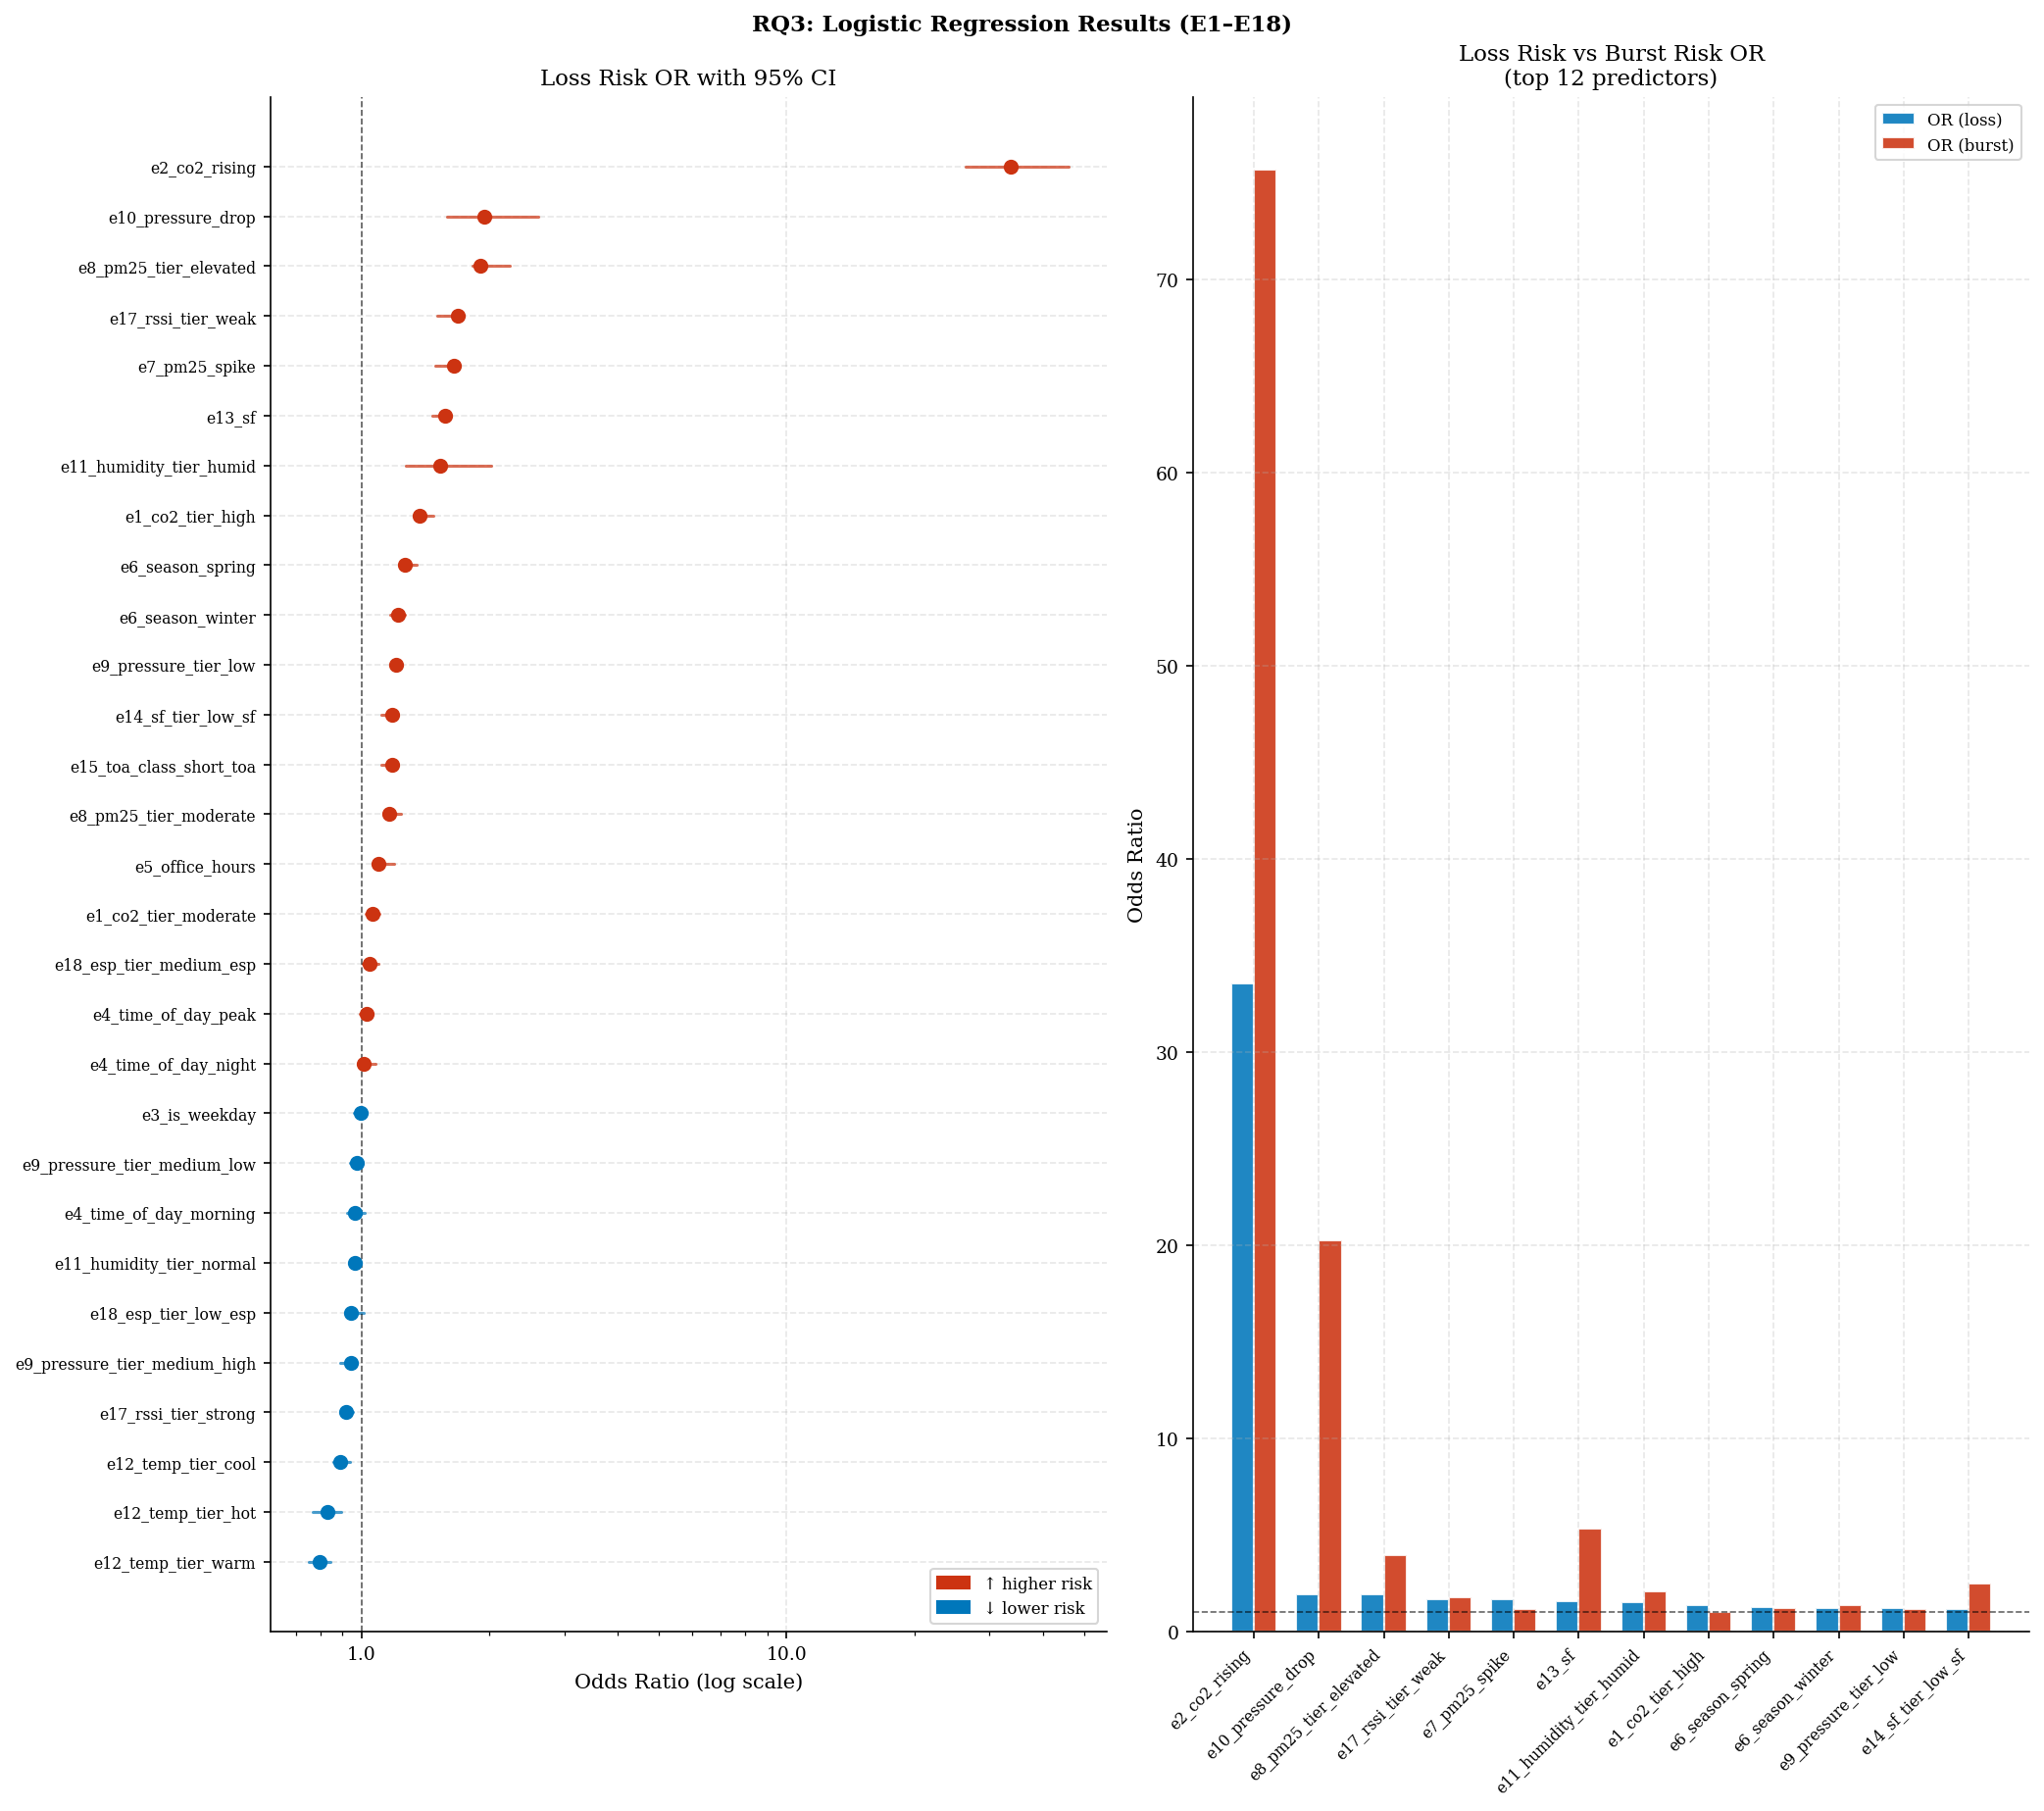

In [37]:
# Fig 03-I — Logistic Regression Forest Plot + Loss vs Burst OR
# or_table built from in-memory odds_ratios and ci_loss — no CSV dependency
# Must run after cell 34 (loss risk model) and cell 37 (burst risk model)


# build unified table from fitted models
ev_rows = []
for feat in feat_names:
    if feat.startswith('device_id'):
        continue
    ev_rows.append({
        'predictor':   feat,
        'OR_loss':     float(odds_ratios.get(feat, 1.0)),
        'loss_CI_lo':  float(ci_loss.loc[feat, 'CI_lo']) if feat in ci_loss.index else 1.0,
        'loss_CI_hi':  float(ci_loss.loc[feat, 'CI_hi']) if feat in ci_loss.index else 1.0,
        'OR_burst':    float(or_burst.get(feat, 1.0)),
        'burst_CI_lo': float(ci_burst.loc[feat, 'CI_lo']) if feat in ci_burst.index else 1.0,
        'burst_CI_hi': float(ci_burst.loc[feat, 'CI_hi']) if feat in ci_burst.index else 1.0,
    })

ev = pd.DataFrame(ev_rows)
ev_loss = ev.sort_values('OR_loss', ascending=True).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, len(ev_loss)*0.38+1.5))

# left: forest plot — loss risk OR with 95% CI
for i, row in ev_loss.iterrows():
    color = C['red'] if row['OR_loss'] > 1 else C['blue']
    axes[0].plot([row['loss_CI_lo'], row['loss_CI_hi']], [i, i],
                  color=color, lw=1.5, alpha=0.7, solid_capstyle='round')
    axes[0].scatter(row['OR_loss'], i, color=color, s=40, zorder=5)
axes[0].axvline(x=1.0, color='black', lw=0.8, ls='--', alpha=0.6)
axes[0].set_yticks(range(len(ev_loss)))
axes[0].set_yticklabels(ev_loss['predictor'], fontsize=7.5)
axes[0].set_xlabel('Odds Ratio (log scale)')
axes[0].set_xscale('log')
axes[0].xaxis.set_major_formatter(mticker.ScalarFormatter())
axes[0].set_title('Loss Risk OR with 95% CI')
axes[0].legend(handles=[mpatches.Patch(color=C['red'],  label='\u2191 higher risk'),
                          mpatches.Patch(color=C['blue'], label='\u2193 lower risk')],
               loc='lower right', fontsize=8)

# right: loss vs burst OR — top 12 by loss OR
ev_top = ev.sort_values('OR_loss', ascending=False).head(12).reset_index(drop=True)
x = np.arange(len(ev_top)); w = 0.35
axes[1].bar(x-w/2, ev_top['OR_loss'],  w, color=C['blue'], alpha=0.88, label='OR (loss)',  edgecolor='white')
axes[1].bar(x+w/2, ev_top['OR_burst'], w, color=C['red'],  alpha=0.88, label='OR (burst)', edgecolor='white')
axes[1].axhline(y=1.0, color='black', lw=0.8, ls='--', alpha=0.6)
axes[1].set_xticks(x)
axes[1].set_xticklabels(ev_top['predictor'], rotation=45, ha='right', fontsize=7.5)
axes[1].set_ylabel('Odds Ratio')
axes[1].set_title('Loss Risk vs Burst Risk OR\n(top 12 predictors)')
axes[1].legend(fontsize=8)

fig.suptitle('RQ3: Logistic Regression Results (E1\u2013E18)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '03_i_logistic_regression')


## 12 · Key Findings Summary  *(§7 summary)*

Thesis-ready statements for Chapter 7.


In [ ]:
print('=' * 65)
print('KEY FINDINGS SUMMARY')
print('=' * 65)

# PDR values needed for Key Findings summary
lost_link    = int(df_link['mac_to_radio_loss'].sum())
pdr_link     = len(df_link) / (len(df_link) + lost_link) * 100
total_app    = int(df['app_to_mac_drop'].sum())
total_radio  = int(df['mac_to_radio_loss'].sum())
pdr_system   = len(df) / (len(df) + total_app + total_radio) * 100
pdr_raw      = len(df) / (len(df) + total_radio) * 100

print(f"""
┌─ RQ1: Campaign-Wide Reliability ────────────────────────────┐
  PDR_system (full pipeline)  : {pdr_system:.2f}%
  PDR_raw    (radio layer)    : {pdr_raw:.2f}%
  PDR_link   (env. losses)    : {pdr_link:.2f}%
  PDR range across 6 devices  : {pdr_range:.2f} pp  ← collision-dominated evidence
  Total intervals analysed    : {len(df_link):,}
└─────────────────────────────────────────────────────────┘
""")

print(f"""
┌─ RQ2: Event-Conditioned PDR ────────────────────────────┐
  Top findings ranked by effect size r:

  {'Event':<6} {'Comparison':<35} {'Diff(pp)':>9} {'r':>8}
  {'-'*62}""")

for _, row in results_df.head(6).iterrows():
    print(f"  {row['Event']:<6} {row['Comparison']:<35} {row['Diff_pp']:>+8.2f} {row['Effect_r']:>8.4f}")

print(f"""
  SF × CO₂ interaction (Table 7.7 — novel finding):
    Background CO₂ : gap = {joint_results['background']['gap']:.2f} pp
    High CO₂       : gap = {joint_results['high']['gap']:.2f} pp
    Widening        : {joint_results['high']['gap'] - joint_results['background']['gap']:.2f} pp → SF×occupancy confirmed
└─────────────────────────────────────────────────────────┘
""")

print(f"""
┌─ RQ3: Strongest Predictors (Logistic Regression) ─────────┐
  AUC = {auc_loss:.3f} (loss risk)  |  AUC = {auc_burst:.3f} (burst risk)

  {'Predictor':<35} {'OR (loss)':>10} {'OR (burst)':>12}
  {'-'*60}""")

top_predictors = [
    'e2_co2_rising', 'e10_pressure_drop', 'e8_pm25_tier_elevated',
    'e7_pm25_spike', 'e1_co2_tier_high'
]
for feat in top_predictors:
    or_l = odds_ratios.get(feat, float('nan'))
    or_b = or_burst.get(feat,   float('nan'))
    print(f"  {feat:<35} {or_l:>10.3f} {or_b:>12.3f}")

print(f"""
  Device fixed effects (relative to ED0):
    ED5 OR = {odds_ratios.get('device_id_ED5', float('nan')):.3f} — lower loss risk → supports collision hypothesis
└─────────────────────────────────────────────────────────┘
""")


## 13 · Save Results


In [41]:
# save complete event results table
results_df.to_csv(DATA_DIR / '3_results.csv', index=False)

# save OR table — loss + burst + 95% CI (Table 7.8)
or_table = pd.DataFrame({
    'predictor':    odds_ratios.index,
    'OR_loss':      odds_ratios.values,
    'loss_CI_lo':   [ci_loss.loc[f, 'CI_lo'] for f in odds_ratios.index],
    'loss_CI_hi':   [ci_loss.loc[f, 'CI_hi'] for f in odds_ratios.index],
    'OR_burst':     [or_burst[f] for f in odds_ratios.index],
    'burst_CI_lo':  [ci_burst.loc[f, 'CI_lo'] for f in odds_ratios.index],
    'burst_CI_hi':  [ci_burst.loc[f, 'CI_hi'] for f in odds_ratios.index],
})
or_table.to_csv(DATA_DIR / '3_odds_ratios.csv', index=False)

# save joint SF x CO2 results (Table 7.7)
joint_df = pd.DataFrame(joint_results).T
joint_df.index.name = 'co2_tier'
joint_df.to_csv(DATA_DIR / '3_joint_sf_co2.csv')

print(f'Saved: {DATA_DIR / "3_results.csv"}')
print(f'Saved: {DATA_DIR / "3_odds_ratios.csv"}')
print(f'Saved: {DATA_DIR / "3_joint_sf_co2.csv"}')
print(f'\nNotebook 03 complete.')

Saved: ..\data\3_results.csv
Saved: ..\data\3_odds_ratios.csv
Saved: ..\data\3_joint_sf_co2.csv

Notebook 03 complete.
